**PRCL-0012 : Information Technology Service Management(ITSM)**

**About the Client:**
Client Name : ABC Tech,
Industry : IT-Enabled Business Services,
Size : Mid-Size organization, operating for over a decade
Ticket Volume : 22,000 - 25000 IT incidents / Tickets per year

ABC Tech currenlty follows the ITIL(IT infrastructure Library) framework for managing IT incidents. Their existing processes include:
* Incident Management
* Problem Management
* Change Management
* Configuration   Management
These Processes are considered mature, a recent audit confirmed that further improvements to these processes alone will not give a good return on investment. However, a recent customer survey rated incident Management as poor. So the management is now looking at Machine Learning as the next step to improve things.



**Problem:**
ABC Tech is handling thousands fo IT tickets every year. Despite following good ITIL practices, there are still issues:
* **High Priority Tickets**-->(P1 and P2 tickets are not being predicted early - they surface suddenly and cause disruption)
* **Resource Planning**-->No visibility into how many tickets will come in next quarter or year, leads to understaffing or over-staffing.
* **Wrong Ticket Routing**--> Tickets are being assigned to wrong departments and getting reassigned multiple times, causing delays.
* **Change Failures**--> Changes(RFCs) are sometimes failing or causing misconfigurations, no way to predict this beforehand.





**ML Goals in this Project:**
*  **Task-1 - Predict High Priority Tickets(P1 & P2)**
* **Task-2 - Forecast Incident Volume**
* **Task-3 - Auto-Tag Tickets(Priority + Department)**
* **Task-4 - Predict RFC Failures/ Misconfigurations**




**Data Fields(Columns)**
Understanding each field is key to building the right models:
* CI_Name-->Name of Configuration item
* CI_Cat-->Category of the CI(e.g:Subapplication)
*  CI_Subcat-->Subcategory of the CI(eg:Web based application)
* WBS-->Wrok breakdown structure code(link ticket to a work/project code)
* Incident_ID-->Unique ID  for each incident ticket(eg:IM0000004)
* Status-->Current state of the ticket:Open, Closed, Resolved etc.
* Urgency-->How quickly the issue needs to be resolved
* Impact-->How broadly the issue affects the business(scale:1=high,0=low)
*  Priority-->Fianl priority of the ticket, calculated from (impact+urgency)
*  Category-->Type of ticket,incident, service, request,etc.
* KB_number-->Knowledge base article linked to this ticket.
* Alert_Status-->Status of any monitoring alert linked to this ticket
* No_of_Reassignments-->How many times the ticket was reassigned between teams/agents
* Open_Time-->Date and time when the ticket was first opened
* Reopen_Time-->Date and time if the ticket was responded after resolution.
* Resolved_Time--->Date and time when the ticket was marked resolved.
* Close_Time-->Date and time when the ticket was officially collapsed
* Handle_Time_hrs-->Total time taken to handle the ticket(in hours)
* Closure_Code-->Reason code when closing the ticket(eg. other, fixed, workaround)
* No_of_Related_Interactions-->Number of user contacts/interactions linked to this ticket.
* Related_Interaction-->ID of related service interaction(eg.SD0000007)
* No_of_Related_Changes-->Number of change requestes linked to this ticket
*  Related_Change-->ID of the related change request(eg.C00000056)

**Steps:**
* Connect to the Database
* Understand the data(EDA)
* Clean the data
*  Feature Engineering
* Build the Model(for each task)
* Evaluate the Models
* conclusion









In [ ]:
# Import All the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,roc_auc_score

**Load the dataset**

In [ ]:
df_raw = pd.read_csv("/content/ITSM_data (3).csv")
df = df_raw.copy()

**Basic Checks**

In [ ]:
# Check the shape of data
df.shape

(46606, 25)

In [ ]:
# Check the first 5 row of data
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN


In [ ]:
# check the last 5 row of data
df.tail()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4.0,0.231896,...,NaN,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1.0,SD0147021,NaN,NaN,NaN
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4.0,0.805153,...,NaN,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1.0,SD0146967,NaN,NaN,NaN
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5.0,0.917466,...,NaN,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1.0,SD0146982,NaN,NaN,NaN
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4.0,0.701278,...,NaN,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1.0,SD0146986,NaN,NaN,NaN
46605,DCE000077,hardware,DataCenterEquipment,WBS000267,IM0047057,Closed,3,3,3.0,0.902320,...,NaN,31-03-2014 22:47,31-03-2014 22:47,"0,586388889",Hardware,1.0,SD0147088,NaN,NaN,NaN


In [ ]:
# Check the column names are in readable format.
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [ ]:
# Check the data types of all columns in data
df.dtypes

,0
CI_Name,object
CI_Cat,object
CI_Subcat,object
WBS,object
Incident_ID,object
Status,object
Impact,object
Urgency,object
Priority,float64
number_cnt,float64


In [ ]:
# Check the information of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing_per = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({'Missing Count':missing, 'Missing Percentage':missing_per})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage',ascending=False)
print(missing_df)

                            Missing Count  Missing Percentage
Related_Change                      46046               98.80
No_of_Related_Changes               46046               98.80
No_of_Related_Incidents             45384               97.38
Reopen_Time                         44322               95.10
Resolved_Time                        1780                3.82
Priority                             1380                2.96
Closure_Code                          460                0.99
CI_Cat                                111                0.24
No_of_Related_Interactions            114                0.24
CI_Subcat                             111                0.24
No_of_Reassignments                     1                0.00
Handle_Time_hrs                         1                0.00


In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check the statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CI_Name,46606,3019,SUB000456,3050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CI_Cat,46495,12,application,32900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CI_Subcat,46495,64,Server Based Application,18811,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WBS,46606,274,WBS000073,13342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incident_ID,46606,46606,IM0047057,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,46606,2,Closed,46597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Impact,46606,6,4,22556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Urgency,46606.0,11.0,4.0,15526.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority,45226.0,NaN,NaN,NaN,4.215805,0.705624,1.0,4.0,4.0,5.0,5.0
number_cnt,46606.0,NaN,NaN,NaN,0.499658,0.288634,0.000023,0.248213,0.500269,0.749094,0.999997


**Explanation:**
The Statistical summary shows that the dataset is well-structured with large number of records.Most incidents are application-based and already resolved. Numerical features show low-variance, and categorical features are dominated by a few frequent values. Some preprocessing steps like handling missing values and removing unique identifiers will be necessary before building machine learning models.

In [ ]:
# Handle the Time & hours it is given in comma formatted numbers to clean the column using european number format('3,87,67,221'),
#This kind of Time & hour look messy so, take only first segment of that time before comma as approximation or treat entire time as String.
import re
def parse_handle_time(val):
  try:
    cleaned = str(val).replace(',','.')
    match = re.search(r'\d+\.?\d*',cleaned)
    if match:
      return float(match.group())
      return np.nan
  except:
    return np.nan
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].apply(parse_handle_time)
print('Handle_Time_hrs stats after cleaning :')
print(df['Handle_Time_hrs'].describe())

Handle_Time_hrs stats after cleaning :
count    46605.000000
mean         4.242736
std         15.464223
min          0.000000
25%          0.885000
50%          1.950000
75%          4.360000
max       2050.360000
Name: Handle_Time_hrs, dtype: float64


In [ ]:
# Parse the date columns
date_cols = ['Open_Time','Reopen_Time','Resolved_Time','Close_Time']
for col in date_cols:
  df[col] = pd.to_datetime(df[col],dayfirst=True,errors='coerce')
print('Date Columns Parsed:')
print(df[date_cols].dtypes)
print(df[date_cols].isnull().sum())

Date Columns Parsed:
Open_Time        datetime64[ns]
Reopen_Time      datetime64[ns]
Resolved_Time    datetime64[ns]
Close_Time       datetime64[ns]
dtype: object
Open_Time            0
Reopen_Time      44322
Resolved_Time     1780
Close_Time           0
dtype: int64


In [ ]:
# Clean the numeric columns which is having 'NA' and 'NS' string
for col in ['Impact','Urgency','Priority']:
  df[col] = pd.to_numeric(df[col],errors='coerce')
print('Impact','Urgency','Priority value counts after cleaning:')
for col in ['Impact','Urgency','Priority']:
  print(f'\n{col}:',df[col].value_counts(dropna=False).to_dict())

Impact Urgency Priority value counts after cleaning:

Impact: {4.0: 22556, 5.0: 16741, 3.0: 5234, nan: 1380, 2.0: 692, 1.0: 3}

Urgency: {4.0: 22588, 5.0: 16779, 3.0: 6536, 2.0: 696, 1.0: 6, nan: 1}

Priority: {4.0: 22717, 5.0: 16486, 3.0: 5323, nan: 1380, 2.0: 697, 1.0: 3}


In [ ]:
# Clean the multivalue columns
df['Related_Interaction_Clean'] = df['Related_Interaction'].apply(
    lambda x: 0 if str(x).startswith('#') else 1 if pd.notna(x) else 0
)
# No_of_Reassignemnts
df['No_of_Reassignments'] = pd.to_numeric(df['No_of_Reassignments'],errors='coerce').fillna(0)
df['No_of_Related_Interactions'] = pd.to_numeric(df['No_of_Related_Interactions'],errors='coerce').fillna(0)
df['No_of_Related_Incidents'] = pd.to_numeric(df['No_of_Related_Incidents'],errors='coerce').fillna(0)
df['No_of_Related_Changes'] = pd.to_numeric(df['No_of_Related_Changes'],errors='coerce').fillna(0)
print(df[['No_of_Related_Interactions','No_of_Reassignments','No_of_Related_Incidents','No_of_Related_Changes']].describe())

       No_of_Related_Interactions  No_of_Reassignments  \
count                46606.000000         46606.000000   
mean                     1.147084             1.131807   
std                      2.553841             2.269756   
min                      0.000000             0.000000   
25%                      1.000000             0.000000   
50%                      1.000000             0.000000   
75%                      1.000000             2.000000   
max                    370.000000            46.000000   

       No_of_Related_Incidents  No_of_Related_Changes  
count             46606.000000           46606.000000  
mean                  0.043771               0.012724  
std                   0.602799               0.123554  
min                   0.000000               0.000000  
25%                   0.000000               0.000000  
50%                   0.000000               0.000000  
75%                   0.000000               0.000000  
max                  63.00000

**Exploratory Data Analysis(EDA)**

**Univariate Analysis:**

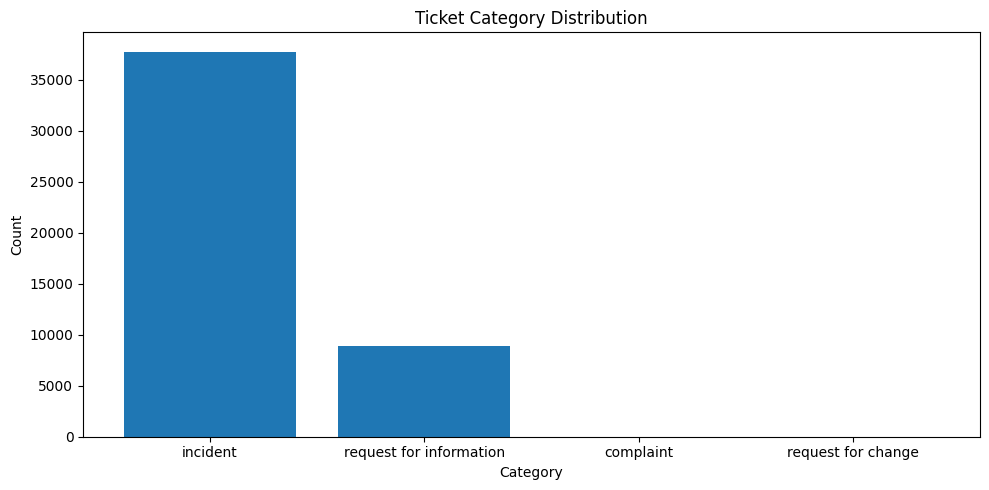

In [ ]:
# Plot for category columns
plt.figure(figsize=(10,5))
cat_counts = df['Category'].value_counts()
plt.bar(cat_counts.index,cat_counts.values)
plt.title('Ticket Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insights:**
The dataset is
dominated by incident tickets, indicating that the service desk primarily handles system or application issues rather than informational requests or complaints.

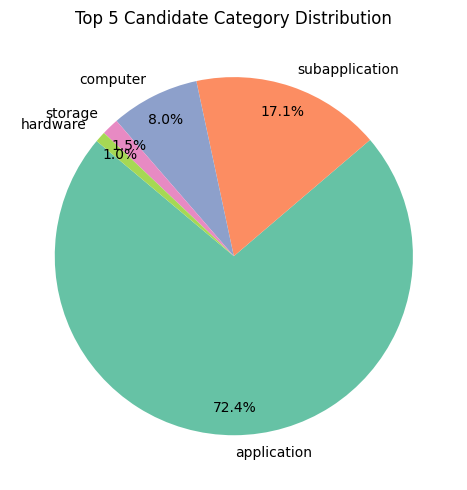

In [ ]:
# Plot top 5 features of Candidate interaction category
plt.figure(figsize=(10,5))
ci_cat = df['CI_Cat'].value_counts().head(5)
plt.pie(ci_cat.values,labels=ci_cat.index,autopct='%1.1f%%',
        colors=sns.color_palette('Set2',len(ci_cat)),startangle=140,
        pctdistance=0.85)
plt.title('Top 5 Candidate Category Distribution')
plt.tight_layout()
plt.show()

**Insights:**
The majority of tickets are related to applications, indicating that software system are the primary source of incidents in the IT environment.

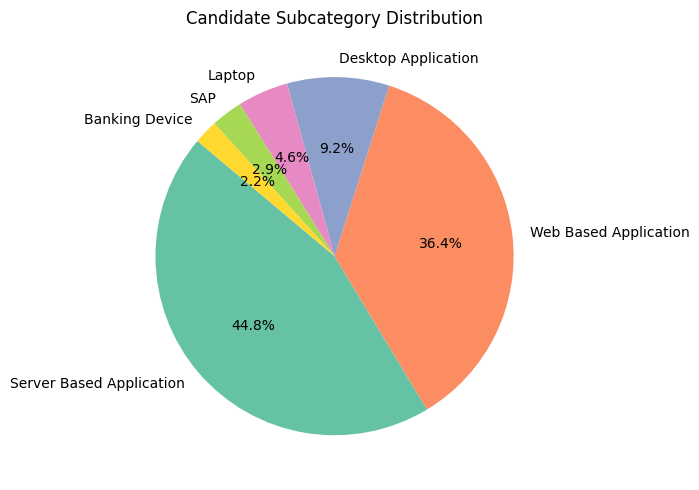

In [ ]:
# Plot top 6 features of  candiate subcateogry
plt.figure(figsize=(10,5))
ci_sub = df['CI_Subcat'].value_counts().head(6)
plt.pie(ci_sub.values,labels=ci_sub.index,autopct='%1.1f%%',
        colors=sns.color_palette('Set2',len(ci_sub)),startangle=140)
plt.title('Candidate Subcategory Distribution')
plt.tight_layout()
plt.show()

**Insights:**
Server-Based and Web-Based applications contribute to the majority of incidents, suggesting that backend infrastructure plays a crucial role in system stability.

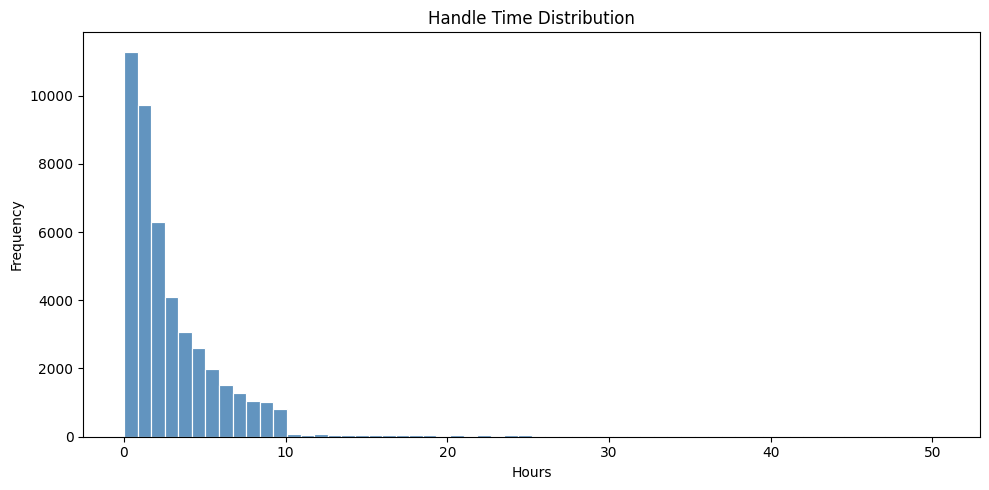

In [ ]:
# Handle time distribution but ensure handle time hours column is numeric before proceeding if not apply the parse function
plt.figure(figsize=(10,5))
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].apply(parse_handle_time)
handle_clean = df['Handle_Time_hrs'].dropna()
handle_clip = handle_clean[handle_clean <  handle_clean.quantile(0.99)]
sns.histplot(handle_clip, bins=60,color='steelblue',edgecolor='white',alpha=0.85)
plt.title('Handle Time Distribution')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Insights:**
The Distribution is right skewed. Most incidents are resolved quickly, but a small number require significantly longer handling time, indicating the presence of complex or escalated issues.

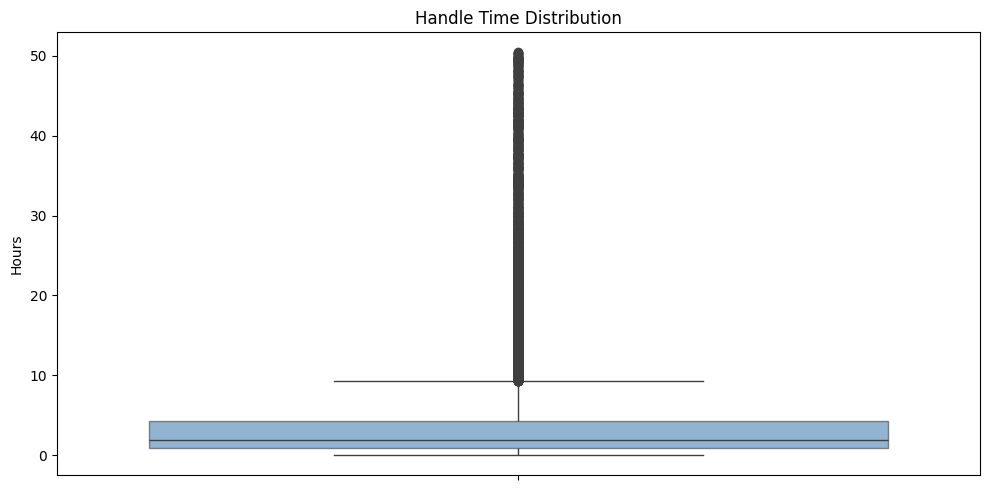

In [ ]:
# Plotting Handle time in boxplot
plt.figure(figsize=(10,5))
sns.boxplot(handle_clip,vert=True,patch_artist=True,
            boxprops=dict(facecolor='steelblue',alpha=0.6))
plt.title('Handle Time Distribution')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

**Insights:**
The median handle time is very low which is (~1-2 hours),suggesting most tickets are resolved quickly. However, there is massive outlier cluster stretching up to 50 hours, pointing to a subset of complex or neglected tickets.The whisker extending to 9-10 hours suggest the normal upper boundary before tickets become outliers.

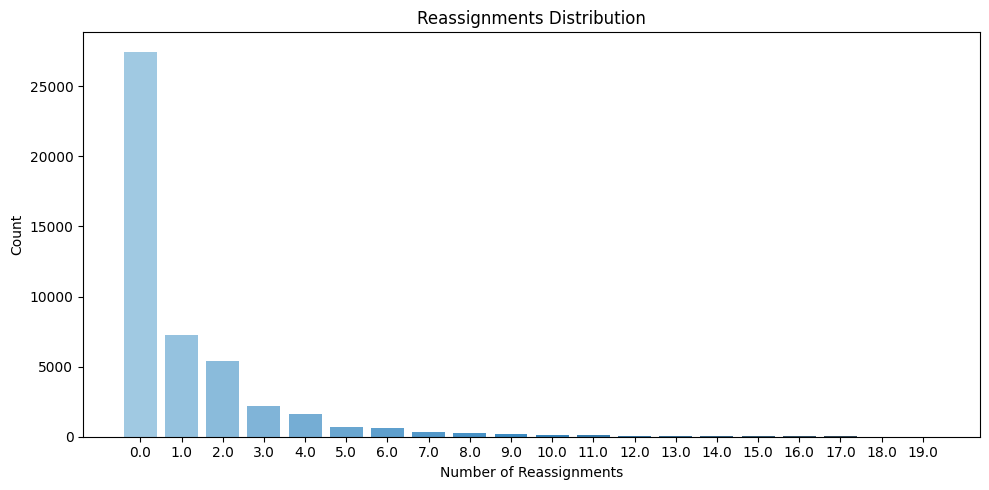

In [ ]:
# Plot of Reassignments
plt.figure(figsize=(10,5))
reass = df['No_of_Reassignments'].value_counts().sort_index()
plt.bar(reass.index[:20].astype(str),reass.values[:20],
        color=sns.color_palette('Blues_d',20))
plt.title('Reassignments Distribution')
plt.xlabel('Number of Reassignments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insights:**
The majority of tickets are resolved without any reassignment. The distribution has a long right tail reaching up to 19.0 reassignments, indicating a small but problematic set of tickets bouncing across teams.

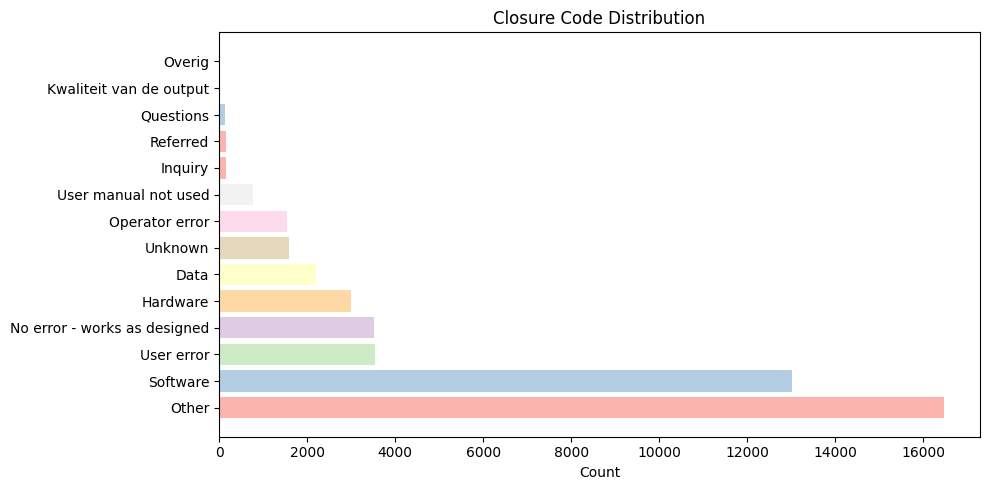

In [ ]:
# Plot for Closure code
plt.figure(figsize=(10,5))
closure = df['Closure_Code'].value_counts()
plt.barh(closure.index,closure.values,color=sns.color_palette('Pastel1',10))
plt.title('Closure Code Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

**Insights:**
The most common closure code(other), which is a redflag it suggest agents are not categorizing resolutions properly, making trend analysis unreliable.

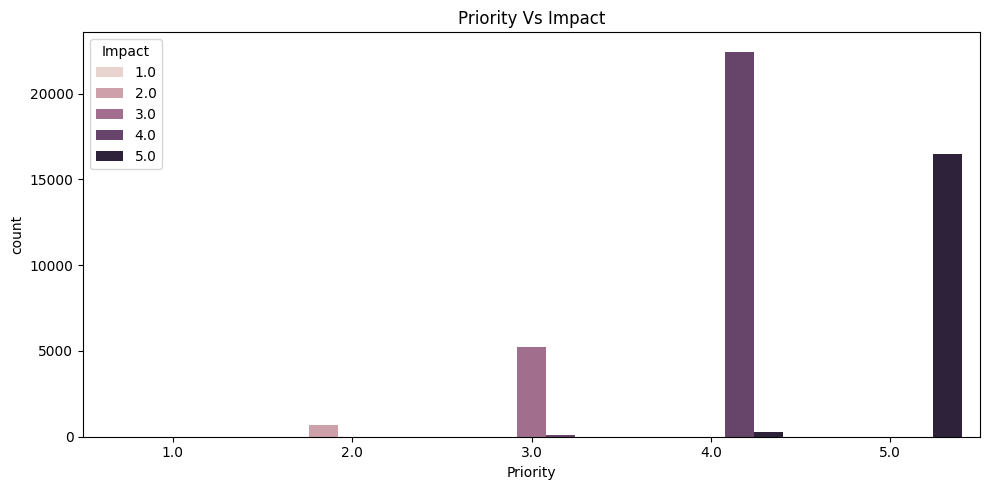

In [ ]:
# plot for priority with impact
plt.figure(figsize=(10,5))
sns.countplot(x='Priority',hue='Impact',data=df)
plt.title('Priority Vs Impact')
plt.tight_layout()
plt.show()

**Observation:**
Higher impact levels are associated with higher priority incidents.

**Insights:**
* This indicates that impact is a key driver in priority assignment,which aligns with ITSM practices where critical business impact leads to urgent handling.
* This plot shows how ticket priority aligns with business impact levels.P1 is nearly empty, impact 1&2 are barely visible across all priorities, suggesting the organization rarely logs low-impact tickets.
The mismatch between priority5 and impact 5 suggests agents may not be correctly aligning urgency with impact when triaging.

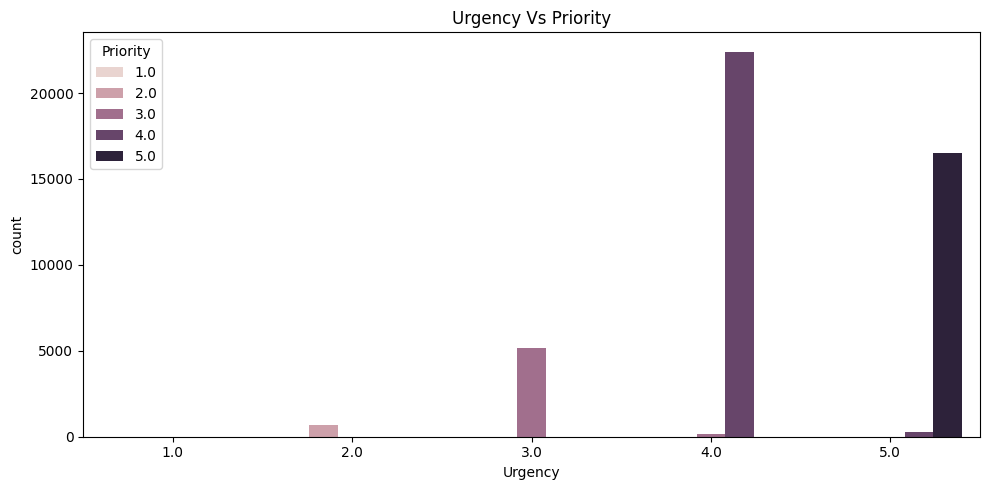

In [ ]:
# Plot for Priority Vs Urgency
plt.figure(figsize=(10,5))
sns.countplot(x='Urgency',hue='Priority',data=df)
plt.title('Urgency Vs Priority')
plt.tight_layout()
plt.show()

**Observation:**
Incidents with higher urgency tend to fall into higher priority categories.

**Insights:**
* Urgency plays a crucial role in determining priority, suggesting that time sensitivity is a mjor factor in incident escalation.

**Bivariate Analsysi:**


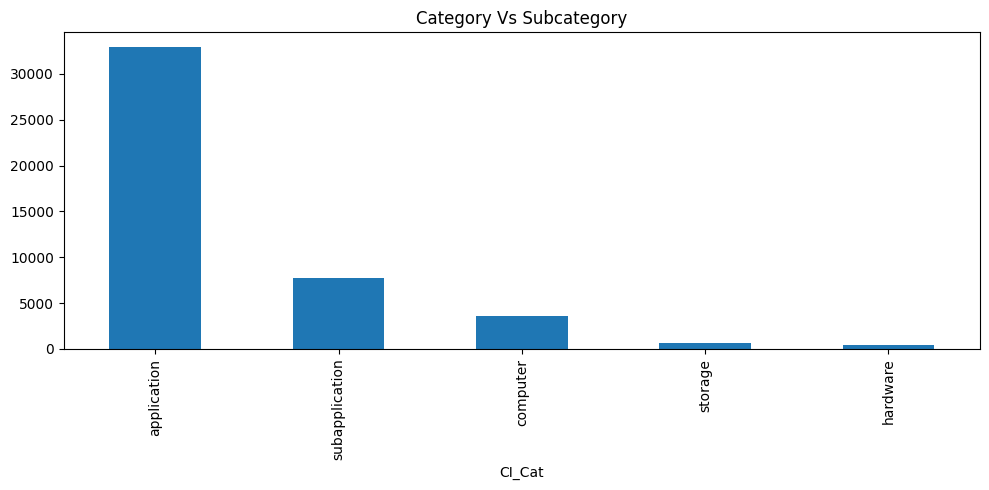

In [ ]:
# Plot for category Vs subcategory
plt.figure(figsize=(10,5))
top_cat = df['CI_Cat'].value_counts().head(5)
top_cat.plot(kind='bar')
plt.title('Category Vs Subcategory')
plt.tight_layout()
plt.show()

**Observation:**
A few categories domincate the incident distribution.

**Insights:**
This suggests recurring issue in specific systems,which can be targeted for long term fixes.

<Figure size 1000x500 with 0 Axes>

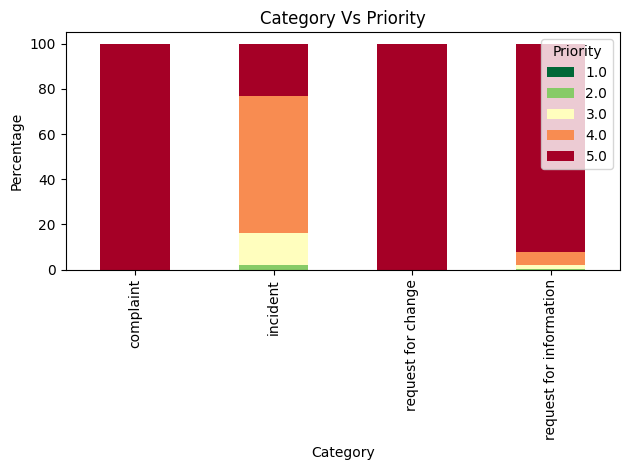

In [ ]:
# Plot for cateogry and priority
ct = pd.crosstab(df['Category'],df['Priority'])
ct_pct = ct.div(ct.sum(axis=1),axis=0)*100
plt.figure(figsize=(10,5))
ct_pct.plot(kind='bar',stacked=True,colormap='RdYlGn_r')
plt.title('Category Vs Priority')
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

**Insights:**
The priority distribution shows a strong imbalance, with most tickets classified as low priority. This reflects real-world ITSM environments where critical incidents are relatively rare.

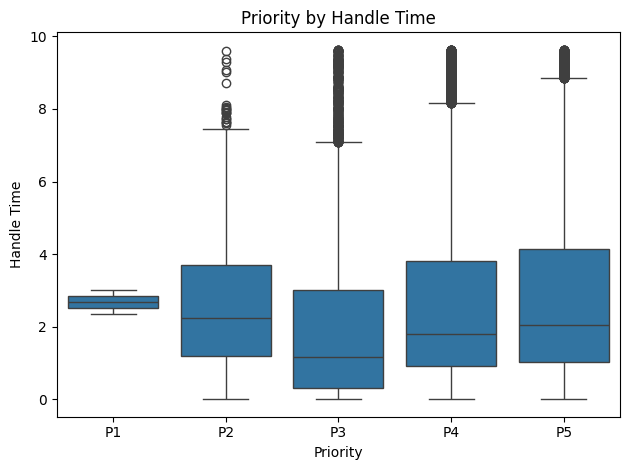

In [ ]:
# Plot Priority based on handle time
priority_groups = df.dropna(subset=['Priority','Handle_Time_hrs'])
priority_groups = priority_groups[priority_groups['Handle_Time_hrs'] < priority_groups['Handle_Time_hrs'].quantile(0.95)]
groups = [priority_groups[priority_groups['Priority'] == p]['Handle_Time_hrs'].values for p in sorted(priority_groups['Priority'].unique())]
sns.boxplot(x='Priority',y='Handle_Time_hrs',data=priority_groups)
plt.xticks(ticks=range(len(priority_groups['Priority'].unique())),labels=[f'P{int(p)}' for p in sorted(priority_groups['Priority'].unique())])
plt.title('Priority by Handle Time')
plt.xlabel('Priority')
plt.ylabel('Handle Time')
plt.tight_layout()
plt.show()

**Insights:**
The high priority tickets have a slightly higher median handle time that low priority,while non-high priority tickets have more extreme outliers.The high priority tickets show tighter outlier clustering at the top, implying some escalation control exists but isn't fully effective.

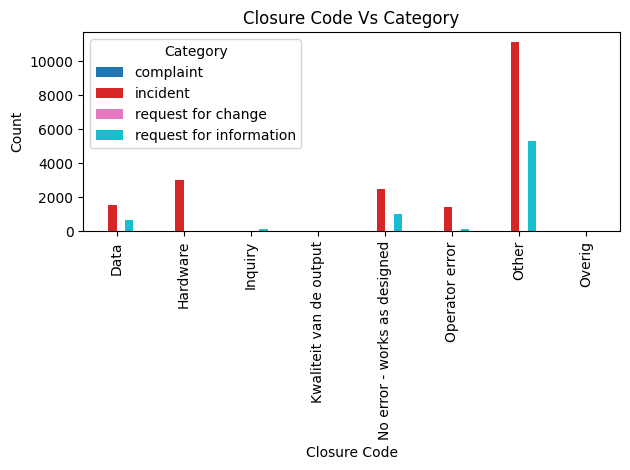

In [ ]:
# Plot for Closure code and category
ct2 = pd.crosstab(df['Closure_Code'],df['Category'])
ct2.head(8).plot(kind='bar',colormap='tab10')
plt.title('Closure Code Vs Category')
plt.xlabel('Closure Code')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insights:**
This analsyis shows that incident dominate ticket resolution, but inconsistent closure coding and frequent use of 'Other' indicate process gaps in ticket documentation and classification.

**Multivariate Analysis:**

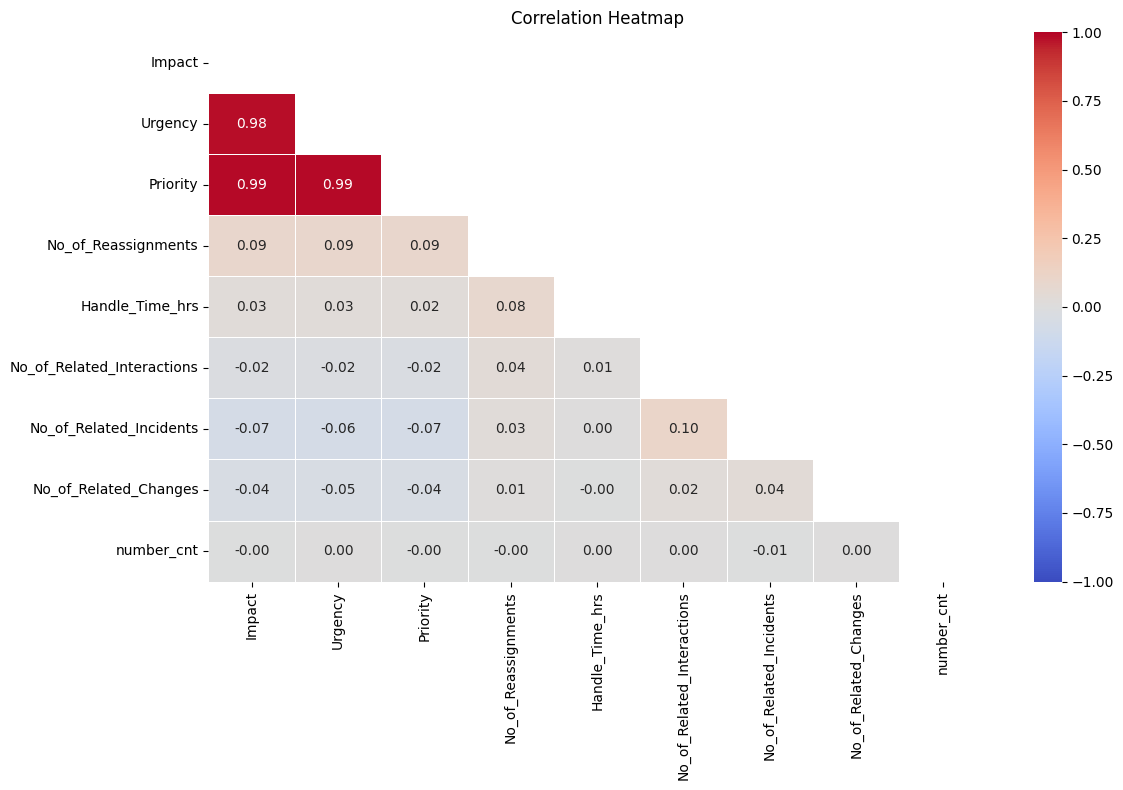

In [ ]:
# Correlation heatmap for all numerical columns
num_cols = ['Impact','Urgency','Priority','No_of_Reassignments','Handle_Time_hrs','No_of_Related_Interactions','No_of_Related_Incidents','No_of_Related_Changes','number_cnt']
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr, mask=mask,annot=True,fmt='.2f',cmap='coolwarm',
            linewidths=0.5,vmin=-1,vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insights:**
The above heatmap reveals that strong multicollinearity among impact,urgency and priority, while most other feature shows weak correlations,inidicating independent behaviour and the need for feature selection.

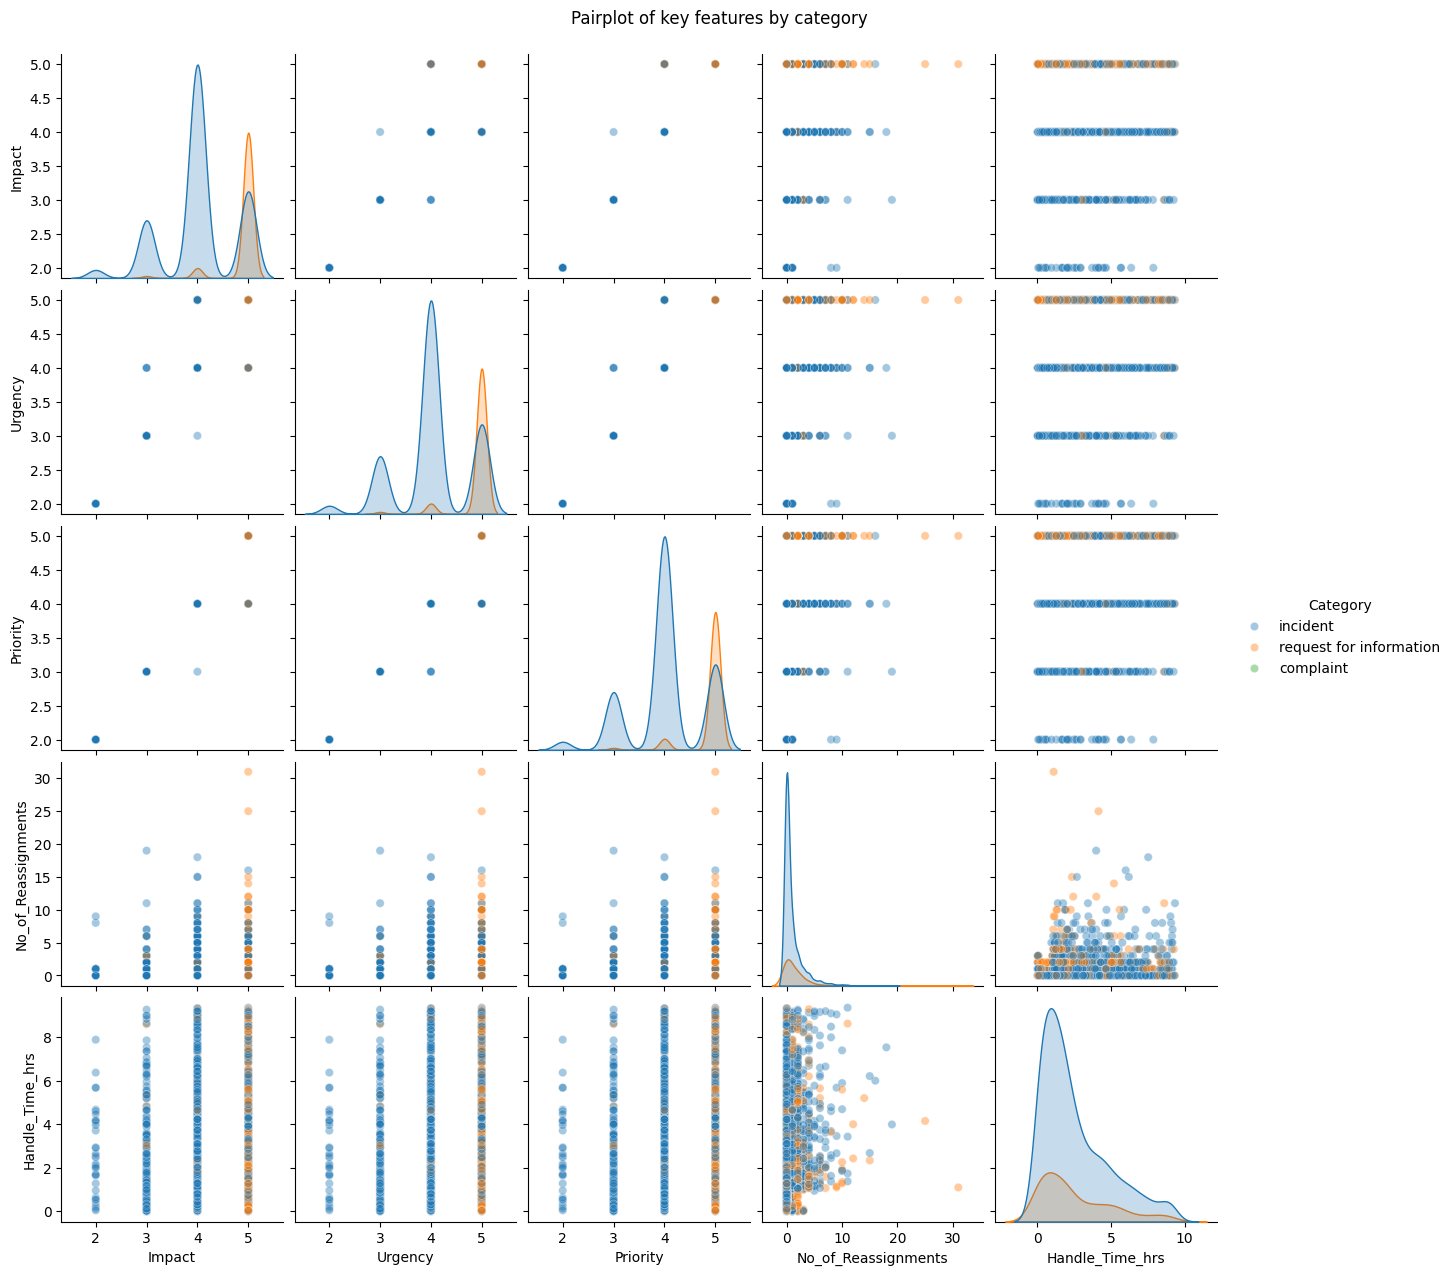

In [ ]:
# Plot for Key features
sample = df[['Impact','Urgency','Priority','No_of_Reassignments','Handle_Time_hrs','Category']].dropna().sample(2000, random_state=42)
sample = sample[sample['Handle_Time_hrs'] < sample['Handle_Time_hrs'].quantile(0.95)]
g = sns.pairplot(sample, hue = 'Category',plot_kws={'alpha':0.4},diag_kind='kde')
g.fig.suptitle('Pairplot of key features by category',y=1.02)
plt.show()

**Insights:**
This pairplot shows strong relationship among impact,urgency, and priority, while most other feature exhibit weak patterns,skewed distributions, and class imbalance across categories.

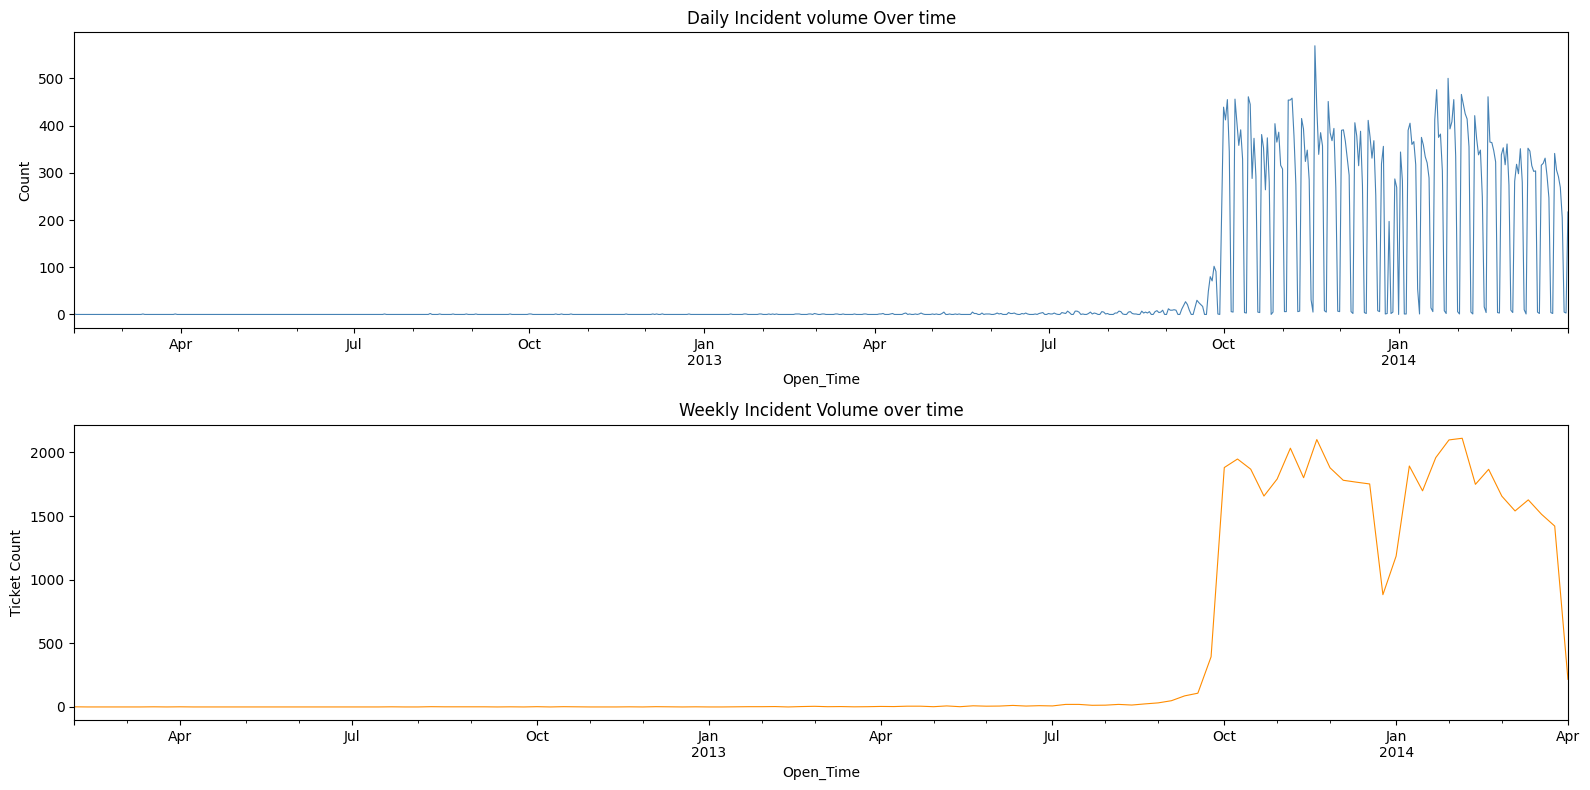

In [ ]:
# Plot for Incident over time
daily_counts = df.set_index('Open_Time').resample('D').size()
weekly_counts = df.set_index('Open_Time').resample('W').size()
fig, axes = plt.subplots(2,1, figsize=(16,8))
daily_counts.plot(ax=axes[0],color='steelblue',linewidth=0.8)
axes[0].set_title('Daily Incident volume Over time')
axes[0].set_ylabel('Count')
weekly_counts.plot(ax=axes[1],color='darkorange',linewidth=0.8)
axes[1].set_title('Weekly Incident Volume over time')
axes[1].set_ylabel('Ticket Count')
plt.tight_layout()
plt.show()

**Insights:**
The suddent spike in incident volume in late 2013 marks a structural shift in system usage or infrastructure complexity, making that period a critical point for root-cause investigation and operational planning.

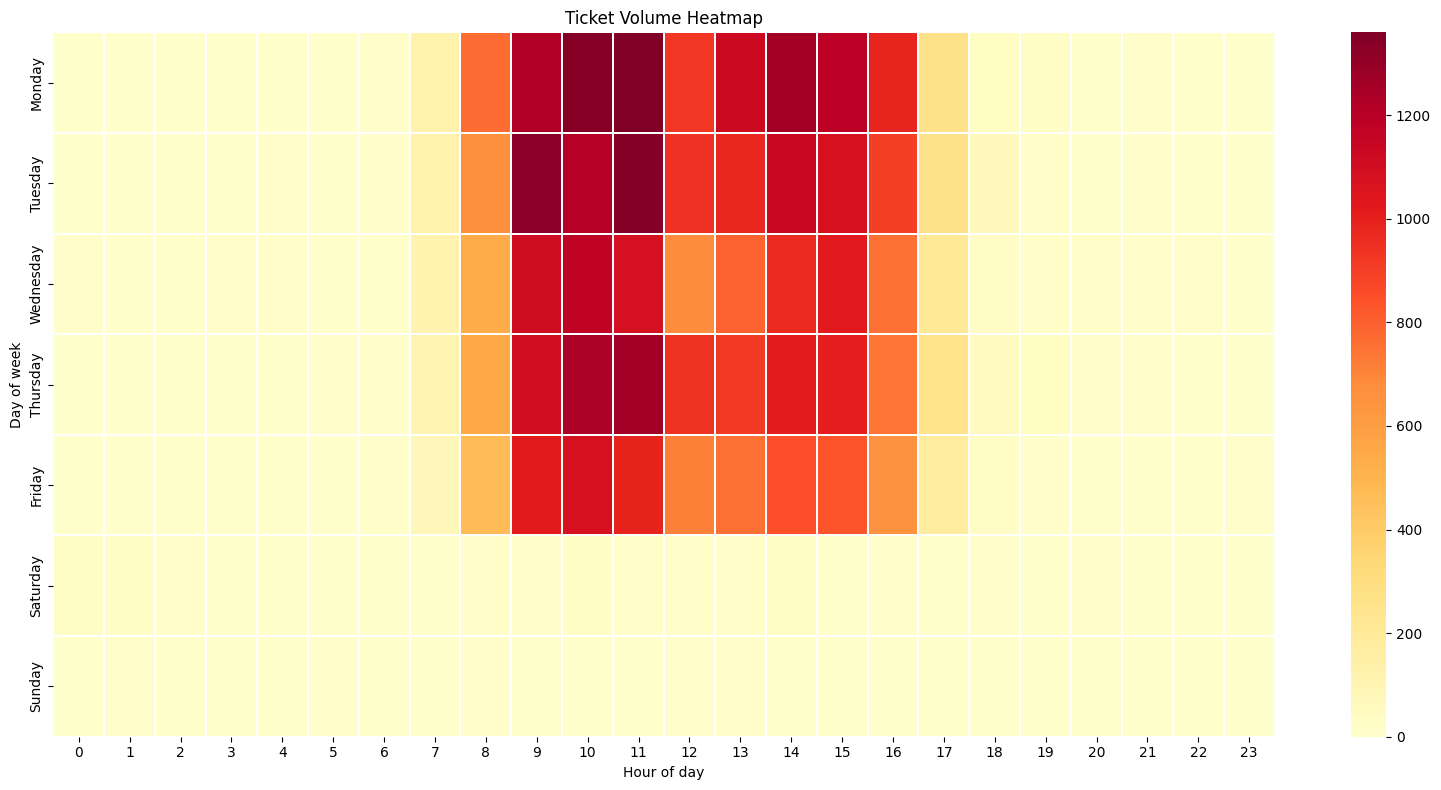

In [ ]:
# Heatmap For Ticket by day, week, and hour
df['Open_DayofWeek'] = df['Open_Time'].dt.day_name()
df['Open_Hour'] = df['Open_Time'].dt.hour
dow_hour = df.groupby(['Open_DayofWeek','Open_Hour']).size().unstack(fill_value=0)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_hour = dow_hour.reindex([d for d in day_order if d in dow_hour.index])
plt.figure(figsize=(16,8))
sns.heatmap(dow_hour,cmap='YlOrRd',linewidths=0.3)
plt.title('Ticket Volume Heatmap')
plt.xlabel('Hour of day')
plt.ylabel('Day of week')
plt.tight_layout()
plt.show()

**Insights:**
* This heatmap clearly shows that ticket volume is heavily concentrated between 8AM and 5PM, Monday through Friday, with weekends and all hours outside that window showing virtually zero activity.
* The Peak Pressure falls on monday through thursday, particularly between 9AM and 12PM where the darkest red cells indicate the highest ticket counts(i.e exceeding 500 in a single hour)
* Thursday around 11AM stands out as the single busiest slot across the entire week. Friday follows a similar morning pattern but tapers off earlier in the afternoon,suggesting users wind down activity heading into the weekend. This pattern has direct staffing implications.
* The support team should be fully resourced by 8AM on weekdays, with maximum capacity available through the late morning hours.

**Detect Outliers Using IQR:**

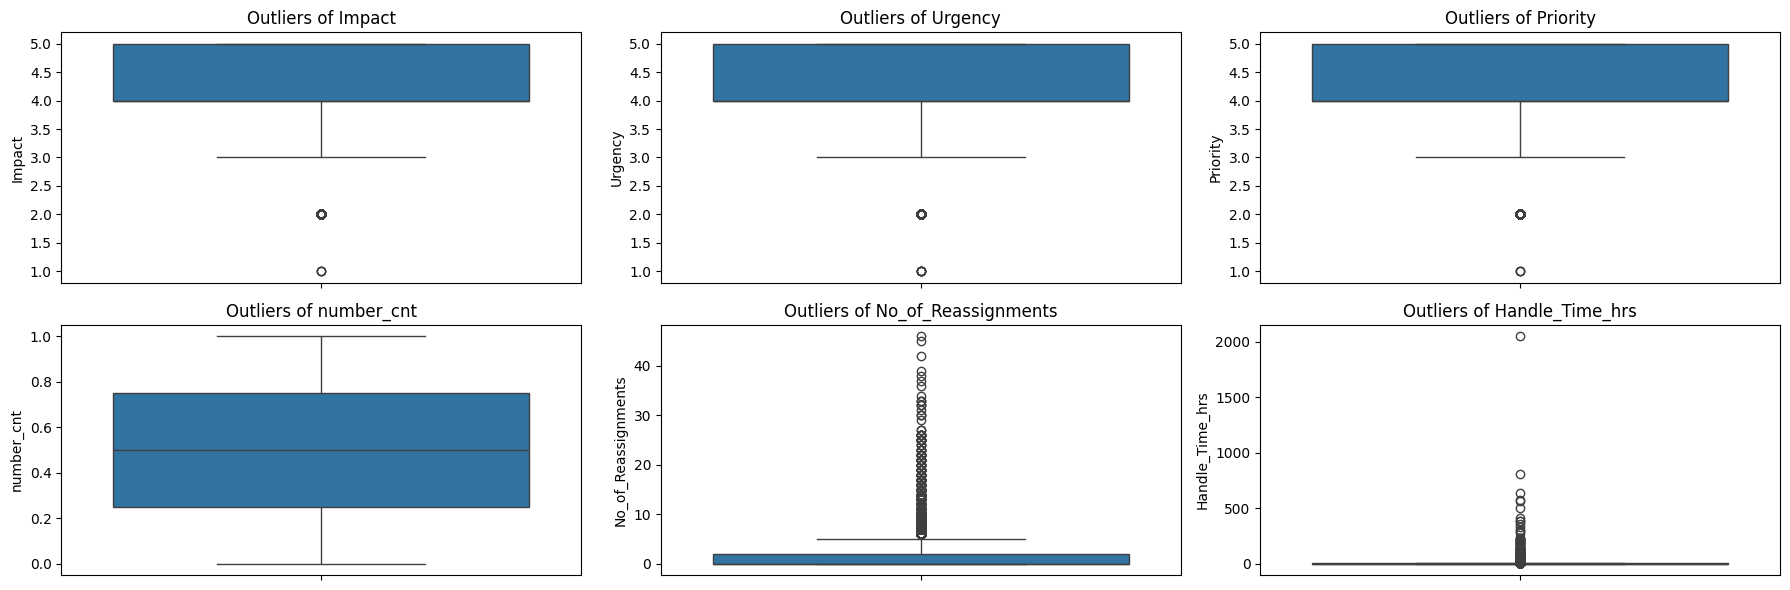

In [ ]:
# Detect outliers for numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns[:6]
plt.figure(figsize=(18,6))
for i, col in enumerate(num_cols):
  plt.subplot(2,3,i+1)
  sns.boxplot(y=df[col])
  plt.title(f'Outliers of {col}')
plt.tight_layout()
plt.show()

**Insights:**
This analysis reveals that most ITSM tickets fall within normal ranges for priority, urgency and impact.I performed Outlier detection to understand the distribution of the data. since the dataset represents real ITSM operational data, extreme values such as very high handle time or resolution time can represent genuine critical incidents rather than errors.Instead, of capping or removing them blindly, i chose to keep them to preserve the real-world behaviour of the system.

**Feature Engineering**

In [ ]:
# Extract the time based features from open time
df['Open_Year'] = df['Open_Time'].dt.year
df['Open_Month'] = df['Open_Time'].dt.month
df['Open_DayofWeek_Num'] = df['Open_Time'].dt.dayofweek
df['Open_Hour']  = df['Open_Time'].dt.hour
df['Open_Quarter'] = df['Open_Time'].dt.quarter
df['Open_WeekofYear'] = df['Open_Time'].dt.isocalendar().week
df['Is_Weekend'] = (df['Open_DayofWeek_Num'] >= 5).astype(int)
df['Is_BusinessHours'] = df['Open_Hour'].between(8,18).astype(int)

In [ ]:
# Convert columns to datetime
df['Open_Time'] = pd.to_datetime(df['Open_Time'],errors='coerce')
df['Resolved_Time'] =pd.to_datetime(df['Resolved_Time'],errors='coerce')

In [ ]:
# Reopen the flag
df['Reopen_Flag'] = df['Reopen_Time'].notna().astype(int)
# Respond Time features
df['Resolution_Time_hrs'] = (df['Resolved_Time'] - df['Open_Time']).dt.total_seconds() / 3600
upper_res = df['Resolution_Time_hrs'].quantile(0.95)
df['Resolution_Time_hrs'] = df['Resolution_Time_hrs'].clip(upper=upper_res)

In [ ]:
# Create and check the daily and hourly tickets
daily_df = df.groupby(df['Open_Time'].dt.date).size().reset_index(name='Incident_Count')
daily_df['Open_Time'] = pd.to_datetime(daily_df['Open_Time'])
daily_df = daily_df.sort_values('Open_Time')
# For weekly tickets
hourly_df = df.groupby(df['Open_Time'].dt.floor('H')).size().reset_index(name='Incident_Count')
hourly_df = hourly_df.sort_values('Open_Time')

In [ ]:
# Forecast of daily tickets
daily_df['Lag_1'] = daily_df['Incident_Count'].shift(1)
daily_df['Lag_7'] = daily_df['Incident_Count'].shift(7)
daily_df['Rolling_Mean_7'] = daily_df['Incident_Count'].rolling(7).mean()
daily_df['Rolling_Std_7'] = daily_df['Incident_Count'].rolling(7).std()
# Forecast of hourly tickets
hourly_df['Lag_1'] = hourly_df['Incident_Count'].shift(1)
hourly_df['Lag_24'] = hourly_df['Incident_Count'].shift(24)
hourly_df['Rolling_Mean_24'] = hourly_df['Incident_Count'].rolling(24).mean()

In [ ]:
# Add features again for daily and hourly tickets
daily_df['Day'] = daily_df['Open_Time'].dt.day
daily_df['Year'] = daily_df['Open_Time'].dt.year
daily_df['DayofWeek'] = daily_df['Open_Time'].dt.dayofweek
daily_df['Month'] = daily_df['Open_Time'].dt.month
daily_df['Quarter'] = daily_df['Open_Time'].dt.isocalendar().week.astype(int)
daily_df['Is_Weekend'] = (daily_df['DayofWeek'] >= 5).astype(int)
# Add lag 20 and rolling 14
daily_df['Lag_30'] = daily_df['Incident_Count'].shift(30)
daily_df['Rolling_14'] = daily_df['Incident_Count'].rolling(14).mean()
# Features for horuly tickets
hourly_df['Hour'] = hourly_df['Open_Time'].dt.hour
hourly_df['DayofWeek'] = hourly_df['Open_Time'].dt.dayofweek
hourly_df['Month'] = hourly_df['Open_Time'].dt.month

**Preprocessing**

In [ ]:
# Encoding
le_dict = {}
cat_encode_cols = ['CI_Cat','CI_Subcat','Alert_Status','Category','Closure_Code']
df_enc = df.copy()
for col in cat_encode_cols:
  le = LabelEncoder()
  df_enc[col + '_enc'] = le.fit_transform(df_enc[col].astype(str))
  le_dict[col] = le
  print(f'{col} : {df_enc[col].nunique()} unique values encoded')

CI_Cat : 12 unique values encoded
CI_Subcat : 64 unique values encoded
Alert_Status : 1 unique values encoded
Category : 4 unique values encoded
Closure_Code : 14 unique values encoded


In [ ]:
# Fill the missing values
fill_cols = ['Impact','Urgency','Priority','Handle_Time_hrs','Resolution_Time_hrs','No_of_Reassignments','No_of_Related_Interactions']
for col in fill_cols:
  df_enc[col].fillna(df_enc[col].median(),inplace=True)
print('Missing values filled with median for numeric features')
print(df_enc[fill_cols].isnull().sum())

Missing values filled with median for numeric features
Impact                        0
Urgency                       0
Priority                      0
Handle_Time_hrs               0
Resolution_Time_hrs           0
No_of_Reassignments           0
No_of_Related_Interactions    0
dtype: int64


**Feature Correlation Heatmap**

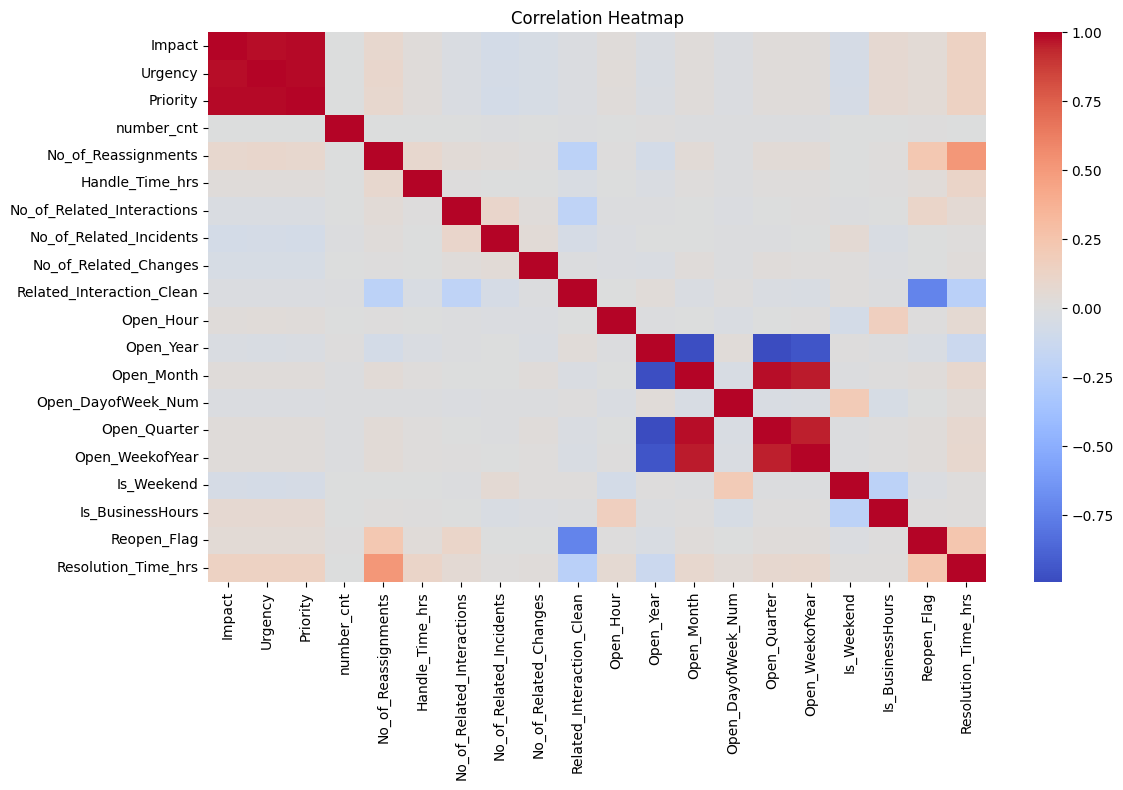

In [ ]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only = True)
sns.heatmap(corr, cmap='coolwarm',annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insights:**
The correlation analysis highlights ticket reassignment and triage accuracy as critical factors influencing resolution time, suggesting that improving initial ticket routing could significantly enhance support efficiency.

**Task-1:**
**Classify High Priority Tickets(P1 & P2)**


In [ ]:
# Create the column high priority and separate into 1 and 2 tickets
df['High_Priority'] = df['Priority'].isin([1,2]).astype(int)

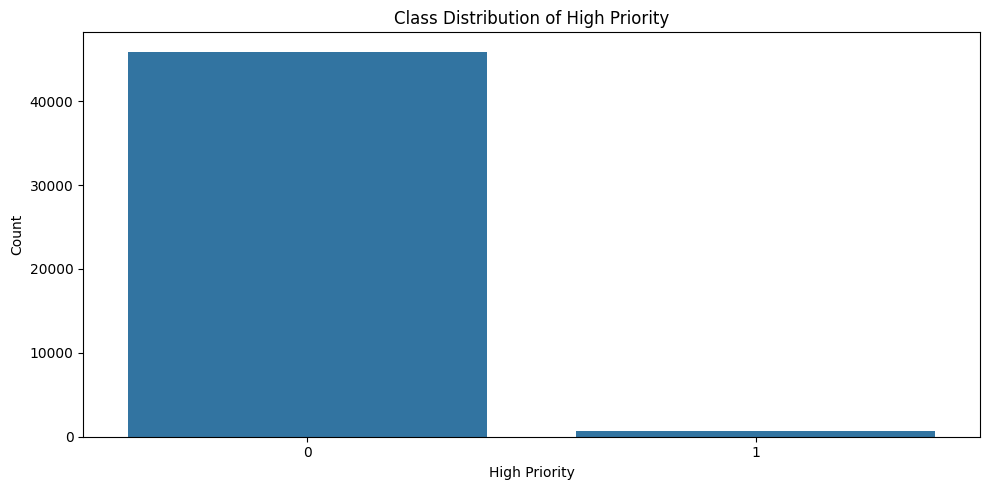

In [ ]:
# Plot High Priority tickets
plt.figure(figsize=(10,5))
sns.countplot(x='High_Priority',data=df)
plt.title('Class Distribution of High Priority')
plt.xlabel('High Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insights:** This plot clearly shows that the the target is highly imbalanced.

In [ ]:
# Build feature and target for high priority prediction
features = [
    'CI_Cat',
    'CI_Subcat',
    'Category',
    'No_of_Reassignments',
    'No_of_Related_Interactions',
    'Alert_Status'
]
X =  df[features]
y = df['High_Priority']

In [ ]:
# Label encoding
le = LabelEncoder()
for col in X.columns:
  X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
# Split the data for train and test
X_train,X_test,y_train,y_test = train_test_split(
    X, y ,test_size=0.2,stratify=y,random_state=42
)

**SMOTE:**
The dataset had severe class imbalance where high peiority tickets were very few. Instead of removing majority class samples through undersampling, which could lead to information loss, I used SMOTE to generate synthetic minority samples and balance the dataset.

In [ ]:
# The target class is imbalanced so we use resampling technique SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train,y_train)

In [ ]:
# After smote applied check the values of target column
print(y_resampled.value_counts())

High_Priority
0    36724
1    36724
Name: count, dtype: int64


**Model Building:**


In [ ]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=200,random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "XGBoost" : XGBClassifier(random_state=42)

}

In [ ]:
results =[]
for name,model in models.items():

    model.fit(X_resampled,y_resampled)

    y_pred =  model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred)
    rec = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob)
    results.append({
      'Model':name,
      'Accuracy':acc,
      'Precision':prec,
      'Recall':rec,
      'F1':f1,
      'ROC_AUC':roc_auc
  })

In [ ]:
# Get the results in DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='ROC_AUC',ascending=False))

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
3    Gradient Boosting  0.972645   0.313916  0.692857  0.432071  0.868089
4              XGBoost  0.952800   0.195122  0.685714  0.303797  0.856601
2        Random Forest  0.953551   0.197938  0.685714  0.307200  0.854427
0  Logistic Regression  0.810234   0.053699  0.700000  0.099746  0.841055
1        Decision Tree  0.953336   0.197125  0.685714  0.306220  0.840439


**Observation:**
Tree-based model such as RandomForest,XGBoost, and LightGBM perform significantly better than simpler models.

**Insights:**
These models capture complex relationships and feature interactions effectively, making them suitable for ITSM ticket classification tasks.

**Expalnation:**
In this project, Mutliple machine learning models were trained to predict high-priority incidents(P1&P2).
Among the baseline models, Gradient boosting performed the best, achieving the highest F1 score (0.43) and ROC_AUC(0.86), indicating strong capability in identifying high priority incidents.However to improve the models precision and recall let's try hyper parameter tuning for tree based models.

Text(50.722222222222214, 0.5, 'Actual')

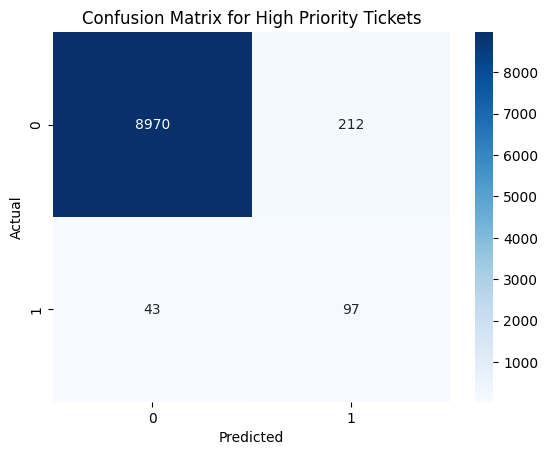

In [ ]:
# Print the confusion matrix
gb_model = models['Gradient Boosting']
y_pred_gb = gb_model.predict(X_test)
cm = confusion_matrix(y_test,y_pred_gb)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix for High Priority Tickets')
plt.xlabel('Predicted')
plt.ylabel('Actual')

**HyperParameter Tuning**

In [ ]:
# Applying Hyperparameter tuning on tree models like RandomForest, GradientBoosting, XGBoost
Models = {
    "Random Forest" :{
        "model" : RandomForestClassifier(),
        "params" : {
            "n_estimators" : [100,200,300],
            "max_depth" : [5,10,20,None],
            "min_samples_split" : [2,5,10],
            "min_samples_leaf" : [1,2,4]
        }
    },
    "Gradient Boosting" : {
        "model" : GradientBoostingClassifier(),
        "params" : {
            "n_estimators" : [100,200,300],
            "learning_rate" : [0.01,0.05,0.1],
            "max_depth" : [3,5,7],
            "subsample":[0.8,1.0]
        }
    },
    "XGBoost" : {
        "model" : XGBClassifier(eval_metric='logloss',use_label_encoder=False),
        "params" : {
            "n_estimators" : [100,200,300],
            "learning_rate" : [0.01,0.05,0.1],
            "max_depth" : [3,5,7],
            "subsample" : [0.8,1.0],
            "colsample_bytree" : [0.8,1.0]
        }
    }
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
results = []
for name, mp in Models.items():
  random_search = RandomizedSearchCV(
      mp["model"],
      mp["params"],
      n_iter =10,
      cv = 3,
      scoring ='f1',
      n_jobs = -1,
      random_state = 42
  )
  random_search.fit(X_resampled,y_resampled)
  best_model = random_search.best_estimator_
  y_pred = best_model.predict(X_test)
  results.append({
      "Model":name,
      "Accuracy":accuracy_score(y_test,y_pred),
      "Precision" :precision_score(y_test,y_pred),
      "Recall": recall_score(y_test,y_pred),
      "F1_score" : f1_score(y_test,y_pred)
  })


In [ ]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy,Precision,Recall,F1_score
2,XGBoost,0.967067,0.269972,0.700000,0.389662
0,Random Forest,0.953551,0.197938,0.685714,0.307200
1,Gradient Boosting,0.953336,0.195876,0.678571,0.304000


**Observation:**
The baseline models show high accuracy but relatively lower precision and recall.

**Insights:**
This indicates class imbalance, where the model is biased toward majority classes and struggles to correctly predict minority classes.


**Explanation:**
The Hyperparameter tuning was applied to tree based models to improve performance.
Because, Low recall for high priority incidents can lead to critical tickets being misclassified,which may result in business impact.
After tuning, XGBoost showed the best performance, achieving the highest recall(0.70) and improved F1 score compared to other models.

**ROC-AUC Curve**

In [ ]:
from sklearn.metrics import roc_curve,auc
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier(eval_metric='logloss')
# Train the models
rf.fit(X_resampled,y_resampled)
gb.fit(X_resampled,y_resampled)
xgb.fit(X_resampled,y_resampled)
# Predict Probabilities
rf_probs = rf.predict_proba(X_test)[:,1]
gb_probs = gb.predict_proba(X_test)[:,1]
xgb_probs = xgb.predict_proba(X_test)[:,1]
# Calculate Roc curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
# Calculate AUC score
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)


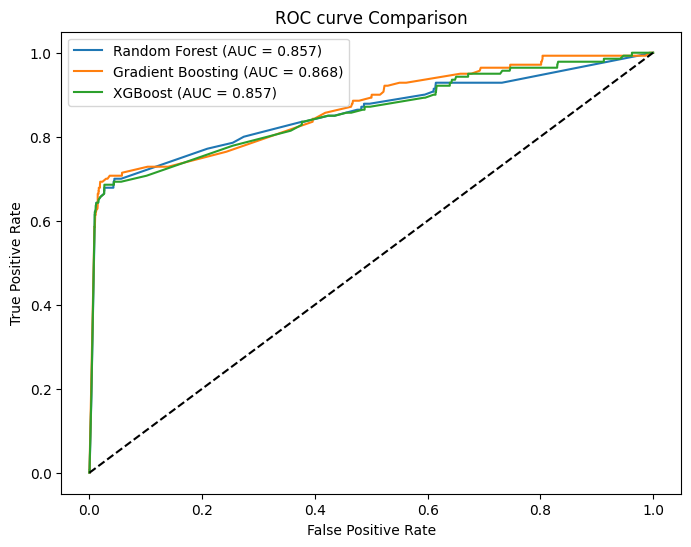

In [ ]:
# Plot ROC-AUC curves
plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label = f'Random Forest (AUC = {rf_auc :.3f})')
plt.plot(gb_fpr, gb_tpr, label = f'Gradient Boosting (AUC = {gb_auc :.3f})')
plt.plot(xgb_fpr, xgb_tpr, label = f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve Comparison')
plt.legend()
plt.show()

**Insights:**
* The ROC curve shows the trade-off between True Positive Rate(Recall) and False positive Rate.
* The closer the curve is to the top-left corner and a model gradient boosting curve stays slightly above the others.
* All three models perform much better than a random classifier(AUC > 0.85),showing predictive ability.
* The model identifies many true positives even at a very low false positive rate, which indicates good classifier quality.


**Shapely Additive Explanation(SHAP)**


Shapely Additive Explanation(SHAP) is used to interpret the predictions of the machine learning model.
It helps to identify how each feature contributes to the prediction outcome by assigning importance values.

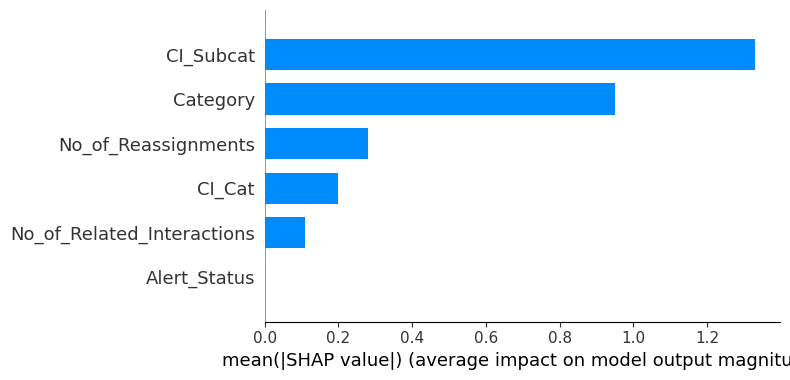

In [ ]:
# Plot for SHAP
import shap
best_model = models['Gradient Boosting']
explainer = shap.TreeExplainer(best_model)
# Calculate shap value for test set
shap_values = explainer.shap_values(X_test)
X_test_proc_df = pd.DataFrame(X_test,columns = X_test.columns)
shap.summary_plot(shap_values,X_test_proc_df,plot_type="bar")

**Observation:**
Features like CI_Cat,Impact,and Priority have the high influence on predictions.

**Insights:**
These features play a crucial role in determining ticket priority,indicating that both technical classification and business impact drive model decisions.

**Model Insights:**

**Observation:**
Among all the models, Gradient Boosting achieved the best balance of performance metrics.

**Insights:**
Gradient Boosting is chosen as the final model due to its ability to handle structured data efficiently and provide better generalization.

**Conclusion for Task-1: High Priority Tickets(P1&P2)**
* Multiple machine learning models were trained to predict high-priority tickets(P1&P2). After comparing the models using Recall,Precision,F1score,Accuracy and ROC_AUC.
* Gradient Boosting performs the best for predicting high-priority tickets because it achieves the highest F1score while maintaining strong recall and precision.
* The TOC curve analysis further confirmed that Gradient Boosting achieved the highest AUC score(0.86)
* This indicates that the model effectively detects critical tickets while minimizing false alerts, making it the most reliable model for operational deployment in IT service management systems.
* Therefore, Gradient Boosting was selected as the final model for predicting high priority tickets.

**Model Saving**

In [ ]:
# Re-run the hyperparameter tuning for Task 1 and capture the best model correctly
# This code captures the best tuned model for Task 1 and saves it.
import joblib

# Assuming the best model from Task 1 (XGBoost from hyperparameter tuning in YqxVxknCt3Qg)
# needs to be explicitly captured and saved. We'll simulate this by re-running the tuning
# and storing the best estimator.
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define the Models dictionary for Task 1 (as in BRwqIxArryBn)
Models_Task1 = {
    "Random Forest" : {
        "model" : RandomForestClassifier(random_state=42),
        "params" : {
            "n_estimators" : [100,200,300],
            "max_depth" : [5,10,20,None],
            "min_samples_split" : [2,5,10],
            "min_samples_leaf" : [1,2,4]
        }
    },
    "Gradient Boosting" : {
        "model" : GradientBoostingClassifier(random_state=42),
        "params" : {
            "n_estimators" : [100,200,300],
            "learning_rate" : [0.01,0.05,0.1],
            "max_depth" : [3,5,7],
            "subsample":[0.8,1.0]
        }
    },
    "XGBoost" : {
        "model" : XGBClassifier(eval_metric='logloss',use_label_encoder=False,random_state=42),
        "params" : {
            "n_estimators" : [100,200,300],
            "learning_rate" : [0.01,0.05,0.1],
            "max_depth" : [3,5,7],
            "subsample" : [0.8,1.0],
            "colsample_bytree" : [0.8,1.0]
        }
    }
}

best_task1_model_estimator = None
# Only tune XGBoost to save the best estimator for Task 1
for name, mp in Models_Task1.items():
    if name == "XGBoost": # Assuming XGBoost was the best for Task 1 after tuning
        random_search = RandomizedSearchCV(
            mp["model"],
            mp["params"],
            n_iter =10,
            cv = 3,
            scoring ='f1',
            n_jobs = -1,
            random_state = 42
        )
        # Ensure X_resampled and y_resampled are correctly defined from Task 1 context
        # These variables are in the global scope from cell 5i0RJqSBoHIG
        random_search.fit(X_resampled,y_resampled)
        best_task1_model_estimator = random_search.best_estimator_
        print(f"Best {name} model for Task 1 identified and captured.")
        break # Exit loop once XGBoost is processed

if best_task1_model_estimator is not None:
    joblib.dump(best_task1_model_estimator, 'Task-1 High_Priority_Tickets.pkl')
    print('Task-1 Model (tuned XGBoost) Saved!')
else:
    print('Error: Best Task 1 model not found or not saved.')


Best XGBoost model for Task 1 identified and captured.
Task-1 Model (tuned XGBoost) Saved!


**Task-2: Incident/Ticket Volume Forecast**

In [ ]:
# Build Daily time series
ts = df.set_index('Open_Time').resample('D').size().reset_index()
ts.columns = ['Date','Count']
ts = ts[ts['Count'] > 0].copy()
# Calendar Features
ts['DayOfWeek'] = ts['Date'].dt.dayofweek
ts['Month'] = ts['Date'].dt.month
ts['Year'] = ts['Date'].dt.year
ts['WeekOfYear'] = ts['Date'].dt.isocalendar().week.astype(int)
ts['Quarter'] = ts['Date'].dt.quarter
ts['Is_Weekend'] = (ts['DayOfWeek'] >= 5).astype(int)
ts['DayOfMonth'] = ts['Date'].dt.day
#Lag features
for lag in [1,3,7,14]:
  ts[f'Lag_{lag}'] = ts['Count'].shift(lag)
# Rolling statistics
ts['Roll_7_mean'] = ts['Count'].shift(1).rolling(7).mean()
ts['Roll_14_mean'] = ts['Count'].shift(1).rolling(14).mean()
ts['Roll_7_std'] = ts['Count'].shift(1).rolling(7).std()
ts.dropna(inplace=True)
ts.reset_index(drop = True, inplace=True)
print(f'Time Series Shape :{ts.shape}')
print(ts.head())

Time Series Shape :(317, 16)
        Date  Count  DayOfWeek  Month  Year  WeekOfYear  Quarter  Is_Weekend  \
0 2012-10-23      1          1     10  2012          43        4           0   
1 2012-11-21      1          2     11  2012          47        4           0   
2 2012-12-05      1          2     12  2012          49        4           0   
3 2012-12-07      1          4     12  2012          49        4           0   
4 2012-12-10      1          0     12  2012          50        4           0   

   DayOfMonth  Lag_1  Lag_3  Lag_7  Lag_14  Roll_7_mean  Roll_14_mean  \
0          23    1.0    1.0    1.0     1.0          1.0      1.071429   
1          21    1.0    1.0    1.0     1.0          1.0      1.071429   
2           5    1.0    1.0    1.0     1.0          1.0      1.071429   
3           7    1.0    1.0    1.0     1.0          1.0      1.071429   
4          10    1.0    1.0    1.0     2.0          1.0      1.071429   

   Roll_7_std  
0         0.0  
1         0.0  
2  

In [ ]:
# train, test and split
Forecast_feature = ['DayOfWeek','Month','Year','WeekOfYear',
                    'Quarter','Is_Weekend','DayOfMonth',
                    'Lag_1','Lag_3','Lag_7','Lag_14',
                    'Roll_7_mean','Roll_14_mean','Roll_7_std']
split_idx = int(len(ts) * 0.8)
train_ts = ts.iloc[:split_idx]
test_ts = ts.iloc[split_idx:]
X_train_ts = train_ts[Forecast_feature]
y_train_ts = train_ts['Count']
X_test_ts = test_ts[Forecast_feature]
y_test_ts = test_ts['Count']

print(f'Train size : {len(train_ts)} | Test Size: {len(test_ts)}')
print(f'Features : {Forecast_feature}')

Train size : 253 | Test Size: 64
Features : ['DayOfWeek', 'Month', 'Year', 'WeekOfYear', 'Quarter', 'Is_Weekend', 'DayOfMonth', 'Lag_1', 'Lag_3', 'Lag_7', 'Lag_14', 'Roll_7_mean', 'Roll_14_mean', 'Roll_7_std']


In [ ]:
# Regressor model for Forecast so import the libraries
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

**ARIMA**

Daily Incident/Ticket volume Forecasting using ARIMA
The dataset is aggregated on a daily basis to analyze incident trends over time.ARIMA is applied to forecast future daily incident volumes.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
df['Open_Time'] = pd.to_datetime(df['Open_Time'])
df.set_index('Open_Time',inplace=True)
daily_incidents = df.resample('D').size()

In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load the Task-1 model (now correctly saved)
model = joblib.load('Task-1 High_Priority_Tickets.pkl')

# These should all print correctly
print("Model type   :", type(model).__name__)
print("Parameters   :", model.get_params())

# Recreate X_test specifically for Task-1 to match training features
task1_features = [
    'CI_Cat',
    'CI_Subcat',
    'Category',
    'No_of_Reassignments',
    'No_of_Related_Interactions',
    'Alert_Status'
]

# Make a copy to avoid modifying the original df for other tasks
df_task1_prep = df.copy()

# Ensure relevant columns are correctly typed for LabelEncoder, handling potential NaNs
for col in task1_features:
    if col in df_task1_prep.columns:
        df_task1_prep[col] = df_task1_prep[col].astype(str)
    else:
        print(f"Warning: Column {col} not found in df_task1_prep. This may lead to errors.")

# Re-apply label encoding as done for Task-1 training
X_task1_pre_split = df_task1_prep[task1_features].copy()
le = LabelEncoder()
for col in X_task1_pre_split.columns:
  X_task1_pre_split[col] = le.fit_transform(X_task1_pre_split[col])

# Re-create y_task1 (High_Priority target)
df_task1_prep['High_Priority'] = df_task1_prep['Priority'].isin([1,2]).astype(int)
y_task1 = df_task1_prep['High_Priority']

# Split the data to get the correct X_test structure and data
_, X_test_task1, _, _ = train_test_split(
    X_task1_pre_split, y_task1, test_size=0.2, stratify=y_task1, random_state=42
)

# Test a prediction using the correctly prepared X_test_task1
sample = X_test_task1.iloc[:3]
print("Prediction   :", model.predict(sample))
print("Probability  :", model.predict_proba(sample))

Model type   : XGBClassifier
Parameters   : {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}
Predict

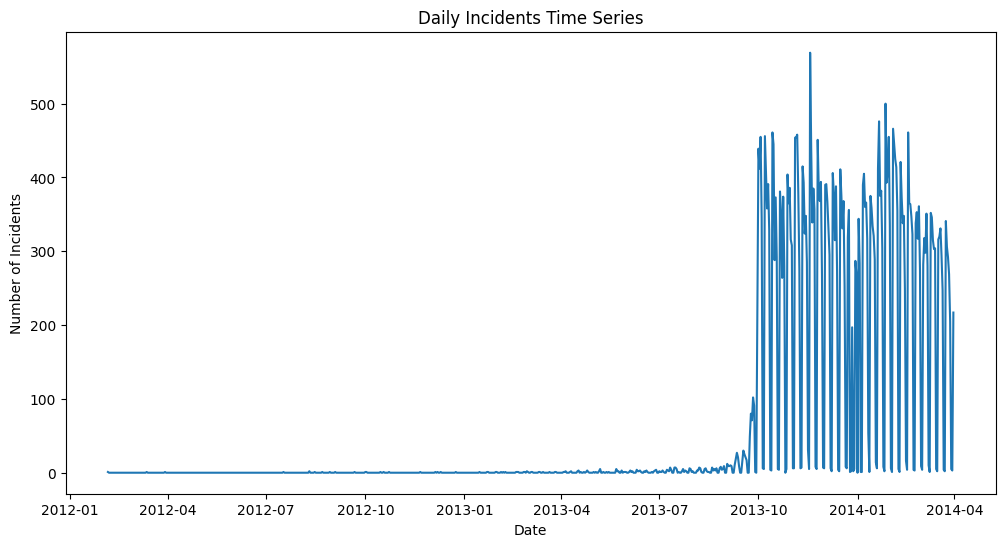

In [ ]:
# Plot times series
plt.figure(figsize=(12,6))
plt.plot(daily_incidents)
plt.title('Daily Incidents Time Series')
plt.xlabel('Date')
plt.ylabel('Number of Incidents')
plt.show()

In [ ]:
# train,test,and split the data
train = daily_incidents[:-10]
test = daily_incidents[10:]

In [ ]:
# Fit ARIMA model
model = ARIMA(train,order=(1,1,1))
model_fit = model.fit()

In [ ]:
# Forecast for daily
forecast = model_fit.forecast(steps=10)

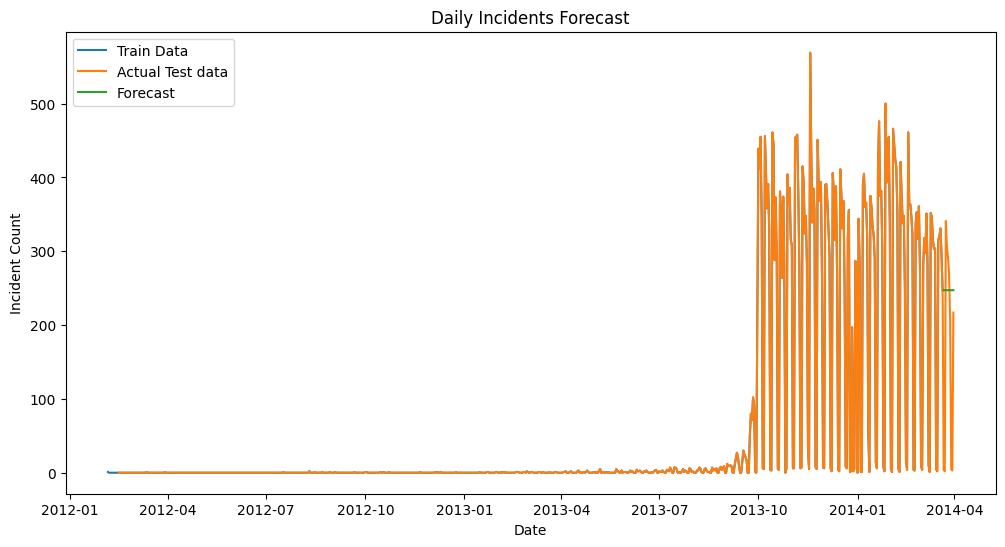

In [ ]:
# plot forecast vs Actual
plt.figure(figsize=(12,6))
plt.plot(train,label = 'Train Data')
plt.plot(test, label = 'Actual Test data')
plt.plot(forecast,label = 'Forecast')
plt.title('Daily Incidents Forecast')
plt.xlabel('Date')
plt.ylabel('Incident Count')
plt.legend()
plt.show()

**Insights:**
The lack of variation in forecast values may indicate that the ARIMA model is capturing stationary pattern in the data. This could also suggest that the dataset does not contain strong seasonal or trend components.

In [ ]:
print('Next 10 days of forecast:')
print(forecast)

Next 10 days of forecast:
2014-03-22    247.499925
2014-03-23    247.175100
2014-03-24    247.386154
2014-03-25    247.249023
2014-03-26    247.338123
2014-03-27    247.280231
2014-03-28    247.317846
2014-03-29    247.293406
2014-03-30    247.309286
2014-03-31    247.298968
Freq: D, Name: predicted_mean, dtype: float64


**Observation:**
The forecasted daily incident volume for the next 10 days remains relatively stable,with values around 247 incdients per day.

**Insights:**
This indicates that there is no significant upward or downward trend in incident volume, suggesting a consistent workload pattern over time.

**Forecast Interpretation:**
The ARIMA model predicts that incident volume will remain steady in the near future, with only minor fluctuations.

**Business Impact:**
Since the workload is stable, IT teams can plan resources efficiently without expecting sudden spikes.However, continuous monitoring is required to handle unexpected surges in incidents.Advance Model like LSTM and Prophet can be used to capture complex patterns.


**PROPHET**
The Prophet is used to predict future values based on historical data,especially when the data has trens,seasonality(daily,weekly, and monthly)
Here using the prophet because the ARIMA forecast the output ~247 incidents every single day with no variation. This happens because ARIMA without a seasonal component cannot model weekly vs weekend swing.So, to understand that we were using the prophet.

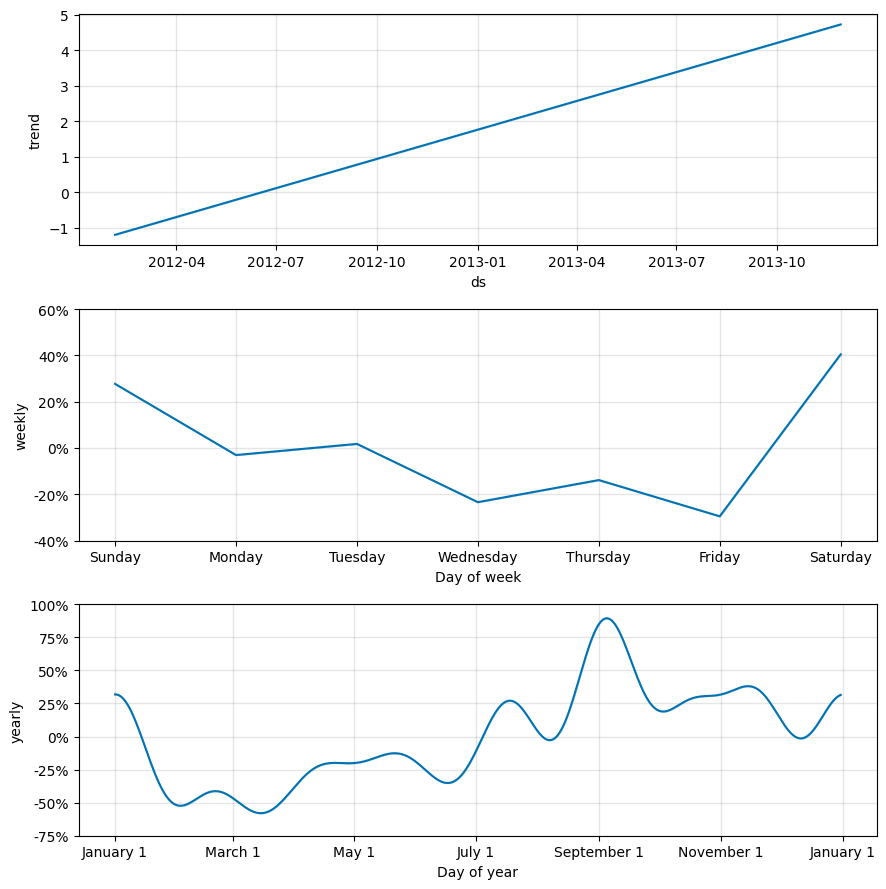

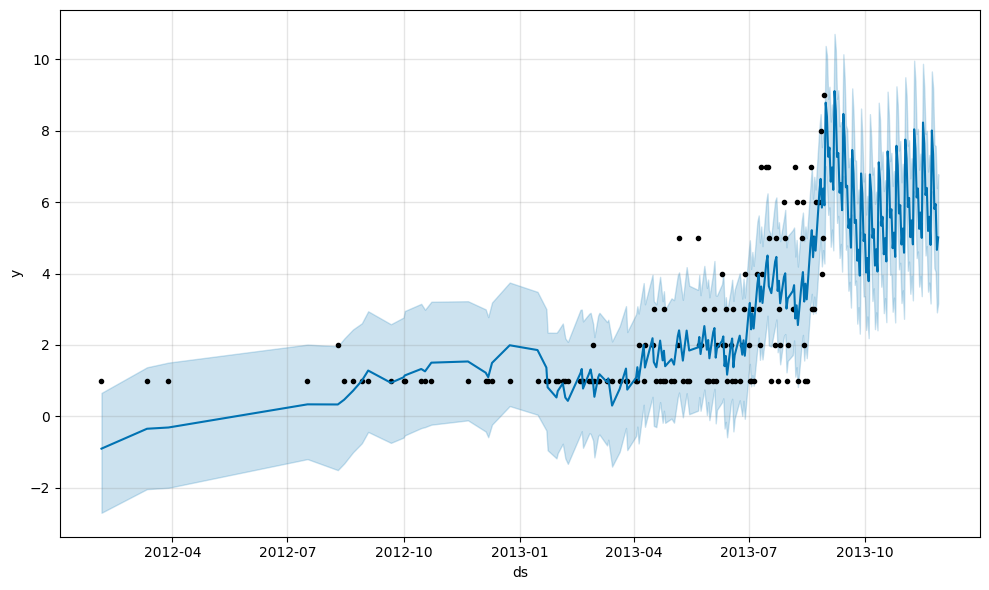

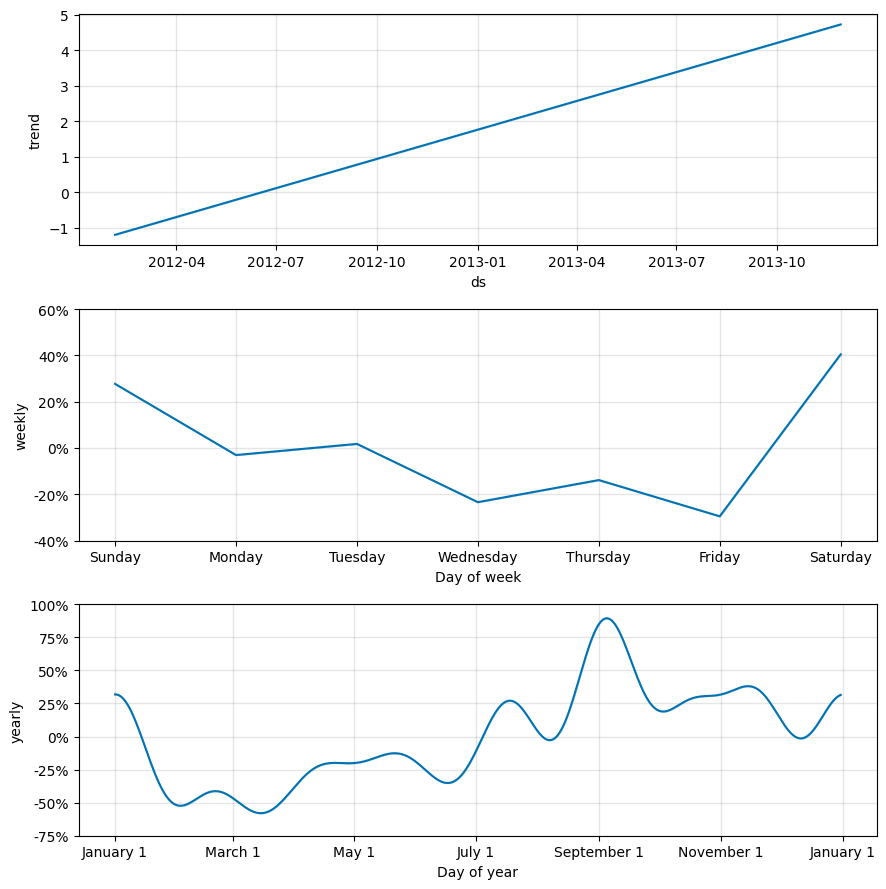

In [ ]:
# To make the visualization to understand the daily,weekly seasonal patterns using prophet
from prophet import Prophet
if df.index.name == 'Open_Time':
  df = df.reset_index()
df['Open_Time'] = pd.to_datetime(df['Open_Time'])
df_ts = df.groupby(df['Open_Time'].dt.date).size().reset_index()
df_ts.columns = ['ds','y']
df_ts['ds'] = pd.to_datetime(df_ts['ds'])
train = df_ts[df_ts['ds'] < '2013-09-01']
m = Prophet(weekly_seasonality=True,daily_seasonality=False,yearly_seasonality=True,seasonality_mode='multiplicative')
m.fit(train)
future = m.make_future_dataframe(periods=90)
forecast = m.predict(future)
m.plot(forecast)
m.plot_components(forecast)

**Observation:**
The trend shows a steady linear increase from 2012 to nearly 2013,which means the incident volume was consistently growing over time.On sunday and saturday the incident are surprisingly high. This shows that weekend incidents are high,but wednesday is quietest day of the week after monday to thursday relatively flat and close to baseline.September is the biggest pattern which corresponds to a fiscal year-end,february is the quietest period of the year,july is mid year summer, and november to december a secondary peak,possibly year-end system changes audit.

**Insights:**
So from the above analysis it is clearly shown that on  weekdays like Sunday and saturday are peak for incidents,when coming to month September is the peak period, then on weedays of Wedneday,and month of February and july are quiet period for incidents.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10,random_state=42),
    "Random Forest" : RandomForestRegressor(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1),
    "XGBoost" : XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42, objective='reg:squarederror'),
    "LGBM" : LGBMRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,verbose=-1)
}

In [ ]:
results = []
for name, model in models.items():
  model.fit(X_train_ts,y_train_ts)
  y_pred = model.predict(X_test_ts)
  mae = mean_absolute_error(y_test_ts,y_pred)
  rmse = np.sqrt(mean_squared_error(y_test_ts,y_pred))
  r2 = r2_score(y_test_ts,y_pred)
  results.append({
      'Model':name,
      'MAE':mae,
      'RMSE':rmse,
      "R2":r2
  })

In [ ]:
# Print the model results
results_df = pd.DataFrame(results).sort_values(by='R2',ascending=False)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,33.196660,42.013093,0.931902
2,Random Forest,30.591941,42.485818,0.930361
4,LGBM,35.480453,52.717361,0.892781
3,XGBoost,38.903019,57.295284,0.873351
1,Decision Tree,46.869544,66.211608,0.830866


**Explanation:**
Incident/Ticket Volume Forecasted on a daily basis to support workforce planning.

**Actual and predicted plot**

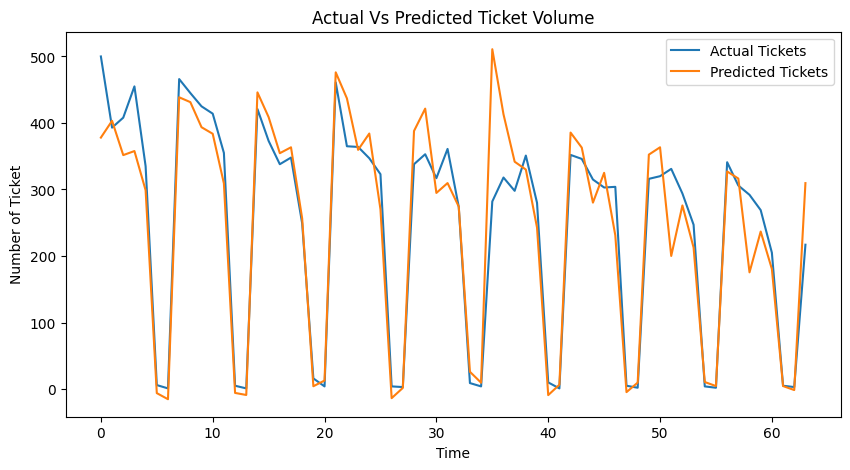

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_ts.values, label = 'Actual Tickets')
plt.plot(y_pred,label='Predicted Tickets')
plt.title('Actual Vs Predicted Ticket Volume')
plt.xlabel('Time')
plt.ylabel('Number of Ticket')
plt.legend()
plt.show()

**Insights:**
The Predicted ticket volumes closely follow the actual ticket trends, indicating that the model effectively captures the temporal patterns and fluctuations in incident volume, with only minor deviations during peak periods.

**Shapely Additive Explanation(SHAP)**

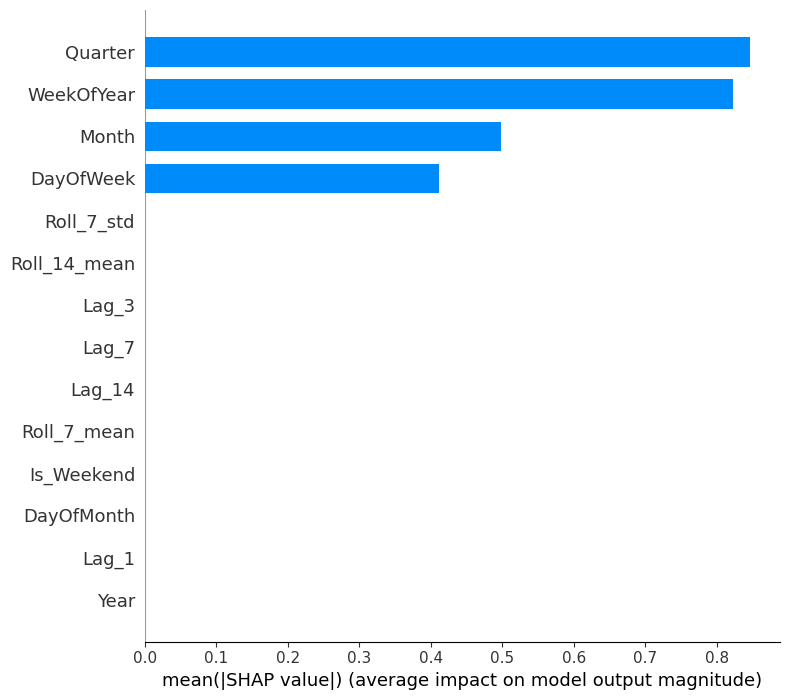

In [ ]:
import shap
explainer = shap.Explainer(best_model,X_train_ts)
shap_values = explainer(X_test_ts)
shap.summary_plot(shap_values, X_test_ts,plot_type='bar')

**Insights:**
SHAP analysis shows that temporal features such as Quarter, WeekOfYear, Month, and DayOfWeek are the most influential factors affecting incident volume predictions, indicating strong seasonal patterns in ticket generation.

**Model Explanations:**
* Classical time series models such as ARIMA or SARIMA were not used because the dataset included multiple engineered temporal features such as Month,Quarter, and DayOfWeek.
* Machine learning regression models were therefore chosen as they can incorporate multiple predictors and capture non-linear relationships.
* SHAP analysis revealed that seasonal calendar features such as Quarter, WeekOfYear, and Month have the strongest influence on ticket volume, indicating that incident generation follows operational and seasonal pattern.

**Conclusion for Task-2: Incident/Ticket Volume Forecast**
* The objective of this task is to forecast future incident/ticket volumes to support predictive proactive workforce planning in IT service Management.
* Multiple Regression models were trained like LinearRegression, XGBoost,LightGBM,DecisionTree and RandomForest were evaluated using MAE,RMSE and R² metrics.
* Among all the models Linear Regression the best predictive performance, achieving r2 score of (~0.93),indicating that model were able to explain around 93% of the variation in the ticket volume.
* Linear Regression achieved the best performance with R²=0.9319 and RMSE =0.42.01,making it the most reliable model for forecasting daily incident volumes.
* The Actual Vs Predicted visualization further confirmed that the predicted ticket volumes closely follow the real ticket trends over time, with only minor deviations during peak periods.


**Model Saving**

In [ ]:
joblib.dump(models['Linear Regression'],'Task-2 Incident_Volume_Forecast.pkl')
print('Task-2 Model Saved!')

Task-2 Model Saved!


**Task-3:Auto-Tagging**

In [ ]:
df['Closure_Code'].value_counts()

,count
Closure_Code,
Other,16470
Software,13027
User error,3554
No error - works as designed,3530
Hardware,2999
Data,2209
Unknown,1590
Operator error,1539
User manual not used,765


In [ ]:
min_samples = 200
valid_classes = df['Closure_Code'].value_counts()
valid_classes = valid_classes[valid_classes >= min_samples].index
df_at = df[df['Closure_Code'].isin(valid_classes)].copy()
print('Remaining Classes:')
print(df_at['Closure_Code'].value_counts())

Remaining Classes:
Closure_Code
Other                           16470
Software                        13027
User error                       3554
No error - works as designed     3530
Hardware                         2999
Data                             2209
Unknown                          1590
Operator error                   1539
User manual not used              765
Name: count, dtype: int64


**Explanation:**
Auto-Tagging is a multi-class classification problem so, a minimum sample threshold was applied to Closure_Code variable to remove rare classes with insufficient data. Classes with fewer than 200 samples were excluded to ensure the model has enough examples to learn meaningful pattern,thereby increasing classification stability and prediction perfomance in the auto-tagging task.

In [ ]:
# Use the label encoder
le = LabelEncoder()
df_at['Closure_Code_enc'] = le.fit_transform(df_at['Closure_Code'])

In [ ]:
# Build the feature and target column for auto tagging
features = ['Priority','Impact','Urgency','Category','CI_Subcat','CI_Cat','No_of_Reassignments','Handle_Time_hrs']
if 'Closure_Code_enc' not in df_at.columns:
  le = LabelEncoder()
  df_at['Closure_Code_enc'] = le.fit_transform(df_at['Closure_Code'].astype(str))
X = df_at[features]
y = df_at['Closure_Code_enc']

In [ ]:
for col in X.columns:
  X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [ ]:
X_train_at,X_test_at,y_train_at,y_test_at = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify =y
)

In [ ]:
# Scale the data
scaler = StandardScaler()
X_train_at_sc = scaler.fit_transform(X_train_at)
X_test_at_sc = scaler.transform(X_test_at)

**Model Building**

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10,random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=200,max_depth=15,random_state=42,n_jobs=-1),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=100,max_depth=5,random_state=42),
    "XGBoost" : XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,use_label_encoder=False,eval_metric='mlogloss',random_state=42,n_jobs=-1),
    "LightGBM":LGBMClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,n_jobs=-1,verbose=-1),
}

In [ ]:
results = []
for name, model in models.items():
  model.fit(X_train_at_sc,y_train_at)

  y_pred = model.predict(X_test_at_sc)
  y_prob = model.predict_proba(X_test_at_sc)

  acc = accuracy_score(y_test_at,y_pred)
  prec = precision_score(y_test_at,y_pred,average='weighted')
  rec = recall_score(y_test_at,y_pred,average='weighted')
  f1 = f1_score(y_test_at,y_pred,average='weighted')
  roc_auc = roc_auc_score(y_test_at,y_prob,multi_class='ovr',average='weighted')
  results.append({
      'Model':name,
      'Accuracy':acc,
      'Precision':prec,
      'Recall':rec,
      "f1-score":f1,
      'ROC_AUC':roc_auc
  })
results_df = pd.DataFrame(results)
results_df.sort_values(by='f1-score',ascending=False)

,Model,Accuracy,Precision,Recall,f1-score,ROC_AUC
4,XGBoost,0.501478,0.471937,0.501478,0.455562,0.753335
3,Gradient Boosting,0.498522,0.462063,0.498522,0.454900,0.752522
5,LightGBM,0.498632,0.465288,0.498632,0.453662,0.750835
1,Decision Tree,0.497100,0.453856,0.497100,0.450974,0.743109
2,Random Forest,0.489767,0.455195,0.489767,0.448194,0.747334
0,Logistic Regression,0.392689,0.307931,0.392689,0.329514,0.668457


**Explanations:**
In this ITSM project i performed auto-tagging task in that i have applied several machine learning classification models and trained using their default parameter settings.The objective of this step was to establish a model and to find how the model is learning the pattern rather then just memorizing and compare how different algorithms perform on the auto-tagging task.

**HyperParameter Tuning**

**Explanation:**
Hyperparameter tuning was performed using RandomizedSearchCV to optimize the performance of tree-based ensemble models.The models are evaluated using weighted precision,recall and F1-score to account for class imbalance in the closure code categories.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
trained_models = {}
results = []
models = {
    "Random Forest":{
        'model':RandomForestClassifier(random_state=42),
        'params':{
            'n_estimators':[200,300,400,500],
            'max_depth':[10,15,20,25,None],
            'min_samples_split':[2,5,10],
            'min_samples_leaf':[1,2,4],
            'max_features':['sqrt','log2']
        }
    },
    'XGBoost':{
        'model':XGBClassifier(eval_metric='mlogloss',
                              use_label_encoder=False,
                              random_state=42),
        'params':{
            'n_estimators':[200,300,400],
            'learning_rate':[0.01,0.05,0.1],
            'max_depth':[3,5,7,10],
            'subsample':[0.7,0.8,1.0],
            'colsample_bytree':[0.7,0.8,1.0],
            'gamma':[0,0.1,0.2]
        }
    },
    'LightGBM':{
        'model':LGBMClassifier(random_state=42),
        'params':{
            'n_estimators':[200,300,400],
            'learning_rate':[0.01,0.05,0.1],
            'max_depth':[-1,5,10,15],
            'num_leaves':[31,50,100],
            'subsample':[0.7,0.8,1.0],
            'colsample_bytree':[0.7,0.8,1.0]
        }
    }
}
for name, mp in models.items():
  random_search = RandomizedSearchCV(
      mp['model'],
      mp['params'],
      n_iter = 20,
      cv = 3,
      scoring = 'f1_weighted',
      n_jobs=-1,
      random_state=42,
      verbose = 1
  )
  random_search.fit(X_train_at_sc,y_train_at)
  best_model = random_search.best_estimator_
  trained_models[name] = best_model
  y_pred = best_model.predict(X_test_at_sc)
  results.append({
      'Model':name,
      'Accuracy':accuracy_score(y_test_at,y_pred),
      'Precision':precision_score(y_test_at,y_pred,average='weighted'),
      'Recall':recall_score(y_test_at,y_pred,average='weighted'),
      'F1 Score':f1_score(y_test_at,y_pred,average='weighted')
  })
results_df = pd.DataFrame(results).sort_values(by='F1 Score',ascending=False)
print(results_df)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
           Model  Accuracy  Precision    Recall  F1 Score
1        XGBoost  0.504651   0.482253  0.504651  0.458594
2       LightGBM  0.504980   0.488874  0.504980  0.458177
0  Random Forest  0.505527   0.496497  0.505527  0.457017


**Explanations:**
After hyperparameter tuning, the performance of tree-based ensemble models improved compared to the baseline models. The tuned models demonstrated better ability to capture patterns in the dataset and classify closure codes more accurately.

**Key Insights:**
* Ensemble tree models outerperformed linear models in predicting closure codes.
* Hyperparameter tuning helped to improve the balance between precision and recall, leading to higher F1-score.
* Models such as XGBoost, and LightGBM achieved the best performance due to their ability to capture complex relationships between ticket features such as Priority, Urgency,Category and handle time.
* The improved results indicate that optimized model parameters allow better learning of patterns in IT service management.


**ROC-AUC Curve**

In [ ]:
from sklearn.preprocessing import label_binarize
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier(eval_metric='mlogloss')
# Train the models
rf.fit(X_train_at_sc,y_train_at)
gb.fit(X_train_at_sc,y_train_at)
xgb.fit(X_train_at_sc,y_train_at)
# predict the probabilities
rf_probs = rf.predict_proba(X_test_at_sc)
gb_probs = gb.predict_proba(X_test_at_sc)
xgb_probs = xgb.predict_proba(X_test_at_sc)
# Number for class and binarize it
n_classes =len(np.unique(y_test_at))
y_test_bin = label_binarize(y_test_at,classes=np.arange(n_classes))
# Compute ROC and AUC
rf_auc = roc_auc_score(y_test_bin,rf_probs,multi_class='ovr')
gb_auc = roc_auc_score(y_test_bin,gb_probs,multi_class='ovr')
xgb_auc = roc_auc_score(y_test_bin,xgb_probs,multi_class='ovr')
# Roc cuve for  one class(example 0)
rf_fpr,rf_tpr,_ = roc_curve(y_test_bin[:,0],rf_probs[:,0])
gb_fpr,gb_tpr,_ = roc_curve(y_test_bin[:,0],gb_probs[:,0])
xgb_fpr,xgb_tpr,_ = roc_curve(y_test_bin[:,0],xgb_probs[:,0])


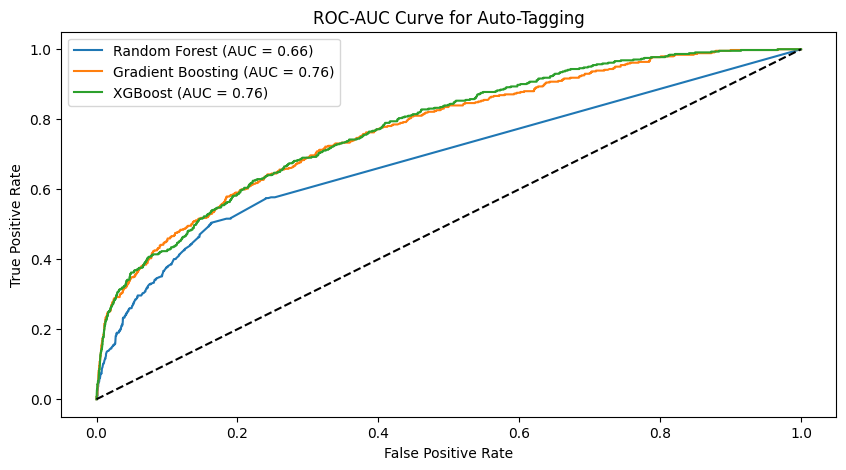

In [ ]:
# plt ROC-AUC curve
plt.figure(figsize=(10,5))
plt.plot(rf_fpr,rf_tpr,label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(gb_fpr,gb_tpr,label=f'Gradient Boosting (AUC = {gb_auc:.2f})')
plt.plot(xgb_fpr,xgb_tpr,label = f'XGBoost (AUC = {xgb_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC-AUC Curve for Auto-Tagging')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Insights:**
According to this ROC-AUC Curve analysis, XGboost and Gradient boosting outperform Random Forest in the auto tagging task. The higher AUC score indicated better capability in distinguishing between closure code categories.

**Shapely Additice Explanation**

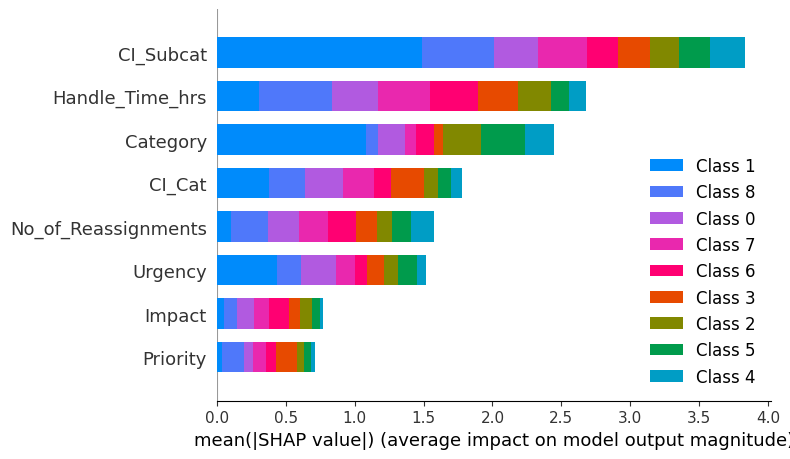

In [ ]:
best_model = XGBClassifier(eval_metric='mlogloss')
best_model.fit(X_train_at_sc,y_train_at)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_at_sc)
shap.summary_plot(shap_values,X_test_at,plot_type='bar')

**Insights:**
* The SHAP analysis shows that CI_Subcat and Handle_Time_hrs are the most influential features in predicting the closure code.
* Category,CI_Cat and No_of_Reassignments have moderate impact, while priority, impact, and urgency contribute less to the prediction.
* This indicates that technical attributes of the ticket play a larger role than priority-based attributes in determining the final closure classification.

**Conclusion of Task-3: Auto-Tagging based on Priority/Department**

* The objective of this task was to build an automated tagging system that predicts the appropriate closure code for IT service tickets based on various ticket attributes such as priority, impact, urgency, category,CI_Category, number of reassignments, and handle time.
* Multiple machine learning models including Logistic Regression, SVM, Decision Tree, Random Forest, Gradient Boosting, and XGBoost were evaluated.   Ensemble tree-based models showed better performance compared to linear models.
* Among all the models XGBoost achieved the best overall performance, with the highest ROC-AUC score and competitive accuracy and F1-score.
* The ROC-AUC curve analysis futher confirmed that XGBoost and gradient boosting have better discrimination ability compared to other models.
* To improve model interpretability, SHAP(Shapley Additive Explanations) was used to analyze feature importance.
*  The SHAP  analysis revealed that features such as priority, category, ci_category, and handle time play a significant role in predicting the closure code.

**Model Saving**


In [ ]:
joblib.dump(trained_models['XGBoost'],'Task-3 Auto-Tagging_model.pkl')
print('Task-3 Model Saved!')

Task-3 Model Saved!


**Task-4: Request for Change**


In [ ]:
def clean_scale(val):
  try:
    v = float(str(val).strip().split()[0])
    return v if 1 <= v <= 5 else np.nan
  except:
    return np.nan
df['Impact'] = df['Impact'].apply(clean_scale)
df['Urgency'] = df['Urgency'].apply(clean_scale)

In [ ]:
# Create the column of RFC because there is no straight column in data to predict
df['RFC'] = (df['Related_Change'].notna() |
             (df['Category'] == 'request for change')).astype(int)
print(f'\n Target Distribution:')
print(df['RFC'].value_counts())
print(f'Imbalance ratio: 1 :{int(df['RFC'].value_counts()[0] / df['RFC'].value_counts()[1])}')


 Target Distribution:
RFC
0    46045
1      561
Name: count, dtype: int64
Imbalance ratio: 1 :82


**Explanation:**
The ITSM dataset did not contain a direct RFC column.Therefore, i derived the target variable using the number fo related changes.If the number of realted changes was greater than zero, it indicates that the incident required a request for change.

In [ ]:
# Add the features again
df['Reopen_Flag'] = df['Reopen_Time'].notna().astype(int)
df['Resolution_Time_hrs'] = (df['Resolved_Time'] - df['Open_Time']).dt.total_seconds() / 3600
df['Open_Hour'] = df['Open_Time'].dt.hour
df['Open_DayOfWeek'] = df['Open_Time'].dt.dayofweek
Features = [
    'Impact',
    'Urgency',
    'Priority',
    'CI_Cat',
    'CI_Subcat',
    'Category',
    'Closure_Code',
    'No_of_Reassignments',
    'No_of_Related_Interactions',
    'No_of_Related_Incidents',
    'Reopen_Flag',
    'Resolution_Time_hrs',
    'Open_Hour',
    'Open_DayOfWeek'
]
Target ='RFC'

In [ ]:
# Separate numerical and categorical columns to apply encoding
cat_cols = ['CI_Cat','CI_Subcat','Category','Closure_Code']
num_cols = [ f for f in Features if f not in cat_cols]

In [ ]:
# Apply label encoding
le_dict = {}
for col in cat_cols:
  df[col] = df[col].astype(str).str.strip().str.lower().fillna('unknown')
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le

In [ ]:
# Define X and y
data = df[Features + [Target]].copy()
X = data[Features]
y = data[Target]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)
print(f'Train Shape : {X_train.shape} | Test Shape: {X_test.shape}')
print(f'Train RFC positives :{y_train.sum()} | Test RFC Positives: {y_test.sum()}')

Train Shape : (37284, 14) | Test Shape: (9322, 14)
Train RFC positives :449 | Test RFC Positives: 112


In [ ]:
# Preprocession pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
preprocessor = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [ ]:
# Highly imbalanced data so apply smote
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc,y_train)
print(f'After SMOTE:')
print(f' RFC = 1 :{y_train_sm.sum()}')
print(f' RFC = 0 :{(y_train_sm == 0).sum()}')
print(f' Ratio: 1 : {int((y_train_sm==0).sum() / y_train_sm.sum())}')

After SMOTE:
 RFC = 1 :36835
 RFC = 0 :36835
 Ratio: 1 : 1


In [ ]:
pos_weight = int((y_train == 0).sum() / y_train.sum())
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced',C=0.1),
    "Random Forest":RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced',min_samples_leaf=2),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=200,random_state=42,learning_rate=0.05,max_depth=4),
    "XGBoost":XGBClassifier(n_estimators=300,random_state=42,scale_pos_weight = pos_weight,learning_rate = 0.05,max_depth=4,eval_metric='aucpr',use_label_encoder=False)
}

In [ ]:
from sklearn.metrics import average_precision_score
results =[]
trained_models ={}
for name, model in models.items():
  model.fit(X_train_sm,y_train_sm)
  trained_models[name] = model
  y_prob = model.predict_proba(X_test_proc)[:,1]
  y_pred = model.predict(X_test_proc)
  pr_auc = average_precision_score(y_test,y_prob)
  roc_auc = roc_auc_score(y_test,y_prob)
  f1_rfc = f1_score(y_test,y_pred,pos_label=1,zero_division=0)
  recall = (y_pred[y_test == 1] == 1).mean() if y_test.sum() > 0 else 0
  prec = (y_test[y_pred == 1] == 1).mean() if y_pred.sum() > 0 else 0
  results.append({
      'Model':name,
      'PR-AUC':pr_auc,
      'ROC-AUC':roc_auc,
      'F1-RFC':f1_rfc,
      'Recall':recall,
      'Precision':prec
  })
results_df = pd.DataFrame(results).sort_values('PR-AUC',ascending = False)
print(results_df)

                 Model    PR-AUC   ROC-AUC    F1-RFC    Recall  Precision
1        Random Forest  0.180533  0.865432  0.262443  0.258929   0.266055
2    Gradient Boosting  0.122432  0.817303  0.143556  0.392857   0.087824
3              XGBoost  0.083811  0.811580  0.048913  0.803571   0.025224
0  Logistic Regression  0.026057  0.696421  0.043985  0.741071   0.022665


In [ ]:
from sklearn.metrics import precision_recall_curve
best_name = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
y_prob_best = best_model.predict_proba(X_test_proc)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_test,y_prob_best)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
print(f'Best Model : {best_name}')
print(f'Optimal Threshold(max F1) : {best_threshold:.3f}')
print(f'Precision threshold: {precisions[best_threshold_idx]:.3f}')
print(f'Recall threshold:{recalls[best_threshold_idx]:.3f}')
print(f'F1-score threshold:{f1_scores[best_threshold_idx]:.3f}')
y_pred_tuned = (y_prob_best >= best_threshold).astype(int)
print(f'Classification report (threshold = {best_threshold:.3f})')
print(classification_report(y_test,y_pred_tuned,target_names=['Not RFC','RFC']))

**Insights:**
The RFC prediction task is the hardest in this project due to the extreme 1:82 class imbalance. The optimal threshold of 0.654(max F1) achieves a precision of 0.37 and recall of 0.24.While recall is modest, even catching 24% of RFC failures early gives the IT team advance warning on roughly 1 in 4 problematic change requests.

**Threshold Otpimization:**
Instead of using the default threshold(0.5), and optimal threshold is selected based on maximizing the F1-score using the precision-Recall curve.
This approach ensures a balanced trade-off between precision and recall, which is especially improtant for imbalanced dataset.

In [ ]:
# Plot for the metrics
fig, axes = plt.subplots(1,3,figsize=(18,5))
# Plot-1 : Precision Recall curve
axes[0].plot(recalls[:-1],precisions[:-1],color='steelblue',lw=2,
             label=f'PR-AUC = {results_df.iloc[0]['PR-AUC']:.3f}')
axes[0].scatter(recalls[best_threshold_idx],precisions[best_threshold_idx],
                color='red',s=100,zorder=5,label=f'Best threshold={best_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision Recall Curve')
axes[0].legend()
axes[0].grid(True,alpha=0.3)
# plot-2 : Confusion matrix
cm = confusion_matrix(y_test,y_pred_tuned)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[1],
            xticklabels=['Not RFC','RFC'],yticklabels=['Not RFC','RFC'])
axes[1].set_title(f'Confusion matrix - {best_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
# Plot-3 : Feature Importance
if hasattr(best_model,'feature_importances_'):
  imp = pd.Series(best_model.feature_importances_,index=Features).sort_values(ascending=True)
  imp.plot(kind='barh',ax=axes[2],color='steelblue')
  axes[2].set_title('Feature Importance')
  axes[2].set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Insights:**
In the above analysis ,the plot is clearly expalining the thing that Random Forest model demonstrates strong performance in identifying nonRFC tickets but has limited recall for RFC tickets due to class imbalance.
* The optimal threshold of 0.65 improves the balance between precision and recall.
* Feature importance analysis  indicates that ticket resolution characteristics, operational attributes, and time-based features are the most significant predictors for RFC classification.
* Further improvements could be achieved through additional feature engineering or advanced ensemble methods.

In [ ]:
# plot for PR-AUC comparison for all ML models
plt.figure(figsize=(8,4))
colors = ['steelblue' if n != best_name else 'tomato' for n in results_df['Model']]
plt.barh(results_df['Model'],results_df['PR-AUC'],color=colors)
plt.xlabel('PR-AUC')
plt.title('PR-AUC Comparison Across models')
plt.tight_layout()
plt.show()

**Insights:**
From the above analysis, the Random Forest model should be selected for deployment, as it provides the best performance in detecting the minority class.

**Shapely Additive Explanations**

In [ ]:
best_model = models['Gradient Boosting']
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
X_test_proc_df = pd.DataFrame(X_test_proc,columns=X_test.columns)
shap.summary_plot(shap_values,X_test_proc_df,plot_type='bar')

**Insights:**
This SHAP analysis shows that closure code and incident related features dominate model predictions ,while traditional ITSM attributes like impact,priority and urgency have minimal impact due to redundancy.

**Conclusion of Taks-4:Predict Request For Change(RFC)**
* The goal of this task was to predict whether an IT incident is linked to a request for change(RFC),enabling IT teams to proactively identify change-related failures before they cause disruptions.
* The dataset did not contain a direct RFC column, the target variable was derived by checking if a ticket had a related change request or belong to the 'RFC' category.
* Multiple models were evaluated using PR-AUC as the primary metric, which is the most appropriate metric for extreme class imbalance problems.
* The default  threshold 0.5 was not suitable for this imbalanced task.so,Precision-Recall curve analysis identified 0.654 as the optimal threshold(max F1).
* At threshold = 0.654:
- Precision : 0.37 → 37% of flagged RFCs are genuinely change-related
- Recall    : 0.24 → 24% of actual RFCs are detected early
- F1-Score  : 0.29
* The extreme 1:82 imbalance limits model performance. Future improvements such as collecting
more RFC samples, engineering richer features (e.g. change history, CI risk scores), or
using anomaly detection techniques could significantly boost recall.

**Model Saving**

In [ ]:
joblib.dump(trained_models['Random Forest'],'Task-4 RFC_model.pkl')
print('Task-4 Model Saved!')

**Challenges Faced:**
* The ITSM data is highly imabalanced.
* So,Handling class imbalance and feature engineering were the most challenging part because the contains very few high priority and request for changes and also this requires careful preprocessing.
* The dataset is structured tabular data, and tree based models like Random Forest,XGBoost, and LightGBM generally perfom better on tabular data.
* These tree based algorithms are faster to train, easier to interpret, and work well with mixed feature types.

**Why not ANN:**
The ITSM is consist of tabular data,although ANN can be used for tabular data, I chose tree-based models like Gradient Boosting, Random Forest because they generally perform better on structured datasets.I did experiment with ANN in this project,but it resulted in higher false positives and slightly lower precision.Gradient Boosting achieved better F1-score and ROC-AUC,making it more suitable for this project. In my case, these models also achieved better performance compared to ANN.

**Data leakage Prevention:**
To avoid data leakage, the dataset was first split into training and testing sets.
All preprocessing steps such as encoding, and scaling were applied only on training data and then transformed on the test data.This ensures that the model does not get access to unseen test information during training, resulting in a fair and unbiased evaluation.

**Future Improvement:**
If more time and resources were available, I would improve the model by increasing additional features such as historical ticket patterns, engineer workload, and textual analysis of ticket description using NLP techniques.
* In real ITSM system, the model could be integrated into the ticketing platform.When a new incident is logged, the model would automatically predict its priority and category, helping support teams prioritize critical issues and reduce response time.


**Conclusion of ITSM:**
The IT service management project demonstrates how machine learning techniques can support IT service management by identifying operational patterns, predicting incident outcomes, and improving decision-making processed. Ensemble learning methods proceed to be the most effective for this dataset, and the analysis highlights the importance of feature engineering and appropriate evaluation metrics when working with imbalanced data. The developed models and insights can help IT teams proactively identify and to the following tasks:
* Early detection of high priority incidents improves response time.
* The incident/Ticket volumes can be forecast so it will be useful to get when we will get high and low.
* Automated Closure code tagging reduce manual ticket categorization.
* Predict request for change(RFC) helps the teams to plan system notification proactively.

**Key Findings:**
* Impact,Urgency and CI_Subcat are the most influential features.
* Tree-based models outperformed other algorithms.
* XGBoost provided the best performance.

**Business Impact:**
* The model can help IT teams prioritize incidents effectively.
* It reduces SLA breaches by identifying high-risk tickets ear
* Improves operational efficiency in IT service management.

**Future Scope:**
* Add NLP features from ticket description text using TF-IDF.
* Deploy models via API using Flask
* Implement real-time prediction pipeline using kafka + model serving.

**All Model Saving**

In [ ]:
import os
models_saved = [
    'Task-1 High_Priority_Tickets.pkl',
    'Task-2 Incident_Volume_Forecast.pkl',
    'Task-3 Auto-Tagging_model.pkl',
    'Task-4 RFC_model.pkl'
]
for m in models_saved:
  loaded = joblib.load(m)
  print(f'{m} Loaded Successfully!({type(loaded).__name__})')

Task-1 High_Priority_Tickets.pkl Loaded Successfully!(XGBClassifier)
Task-2 Incident_Volume_Forecast.pkl Loaded Successfully!(LinearRegression)
Task-3 Auto-Tagging_model.pkl Loaded Successfully!(XGBClassifier)
Task-4 RFC_model.pkl Loaded Successfully!(RandomForestClassifier)
